<a href="https://colab.research.google.com/github/mamezquita/PROYECTO-EEP-LEARNING-NOTICIAS/blob/main/Ejecucion_final_espanola_baseline_roberta_bne.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Baseline — Detección de noticias falsas con RoBERTa-BNE

**Proyecto Integrador · Deep Learning · 2026-2**
Replicación adaptada de Blanco-Fernández, Otero-Vizoso, Gil-Solla & García-Duque (2024),
*"Enhancing Misinformation Detection in Spanish Language with Deep Learning: BERT and RoBERTa
Transformer Models"*, Applied Sciences 14(21): 9729.

---

## Qué hace este notebook

Ajuste fino (*fine-tuning*) directo de **RoBERTa-BNE** (`PlanTL-GOB-ES/roberta-base-bne`)
para clasificación binaria real/falsa sobre noticias políticas en español.

El modelo se usa **tal como viene preentrenado**. No hay DAPT, no hay variante multilingüe,
no hay cambios de arquitectura, no hay comparación contra otros modelos. Solo se añade la
cabeza de clasificación de 2 etiquetas y se ajusta todo el modelo sobre nuestros datos.

## Qué NO hace

- No compara contra BETO, BERTIN ni variantes multilingües (eso es un experimento aparte).
- No hace validación cruzada de 5 pliegues (el paper sí; aquí usamos un conjunto de validación
  fijo, que es más barato y suficiente para fijar la referencia).

## Cómo usarlo

**Solo hay que tocar la celda `§2 CONFIGURACIÓN`.** Cuando llegue el CSV colombiano, se cambia
`RUTA_CSV` y se vuelve a ejecutar todo. Nada más.

## Qué deja guardado en disco

Todo va a la carpeta definida en `DIR_SALIDA`:

| Archivo | Contenido |
|---|---|
| `hiperparametros.json` | Toda la configuración + versiones de librerías + hardware + hash del CSV |
| `particion.csv` | Fila por fila: a qué split fue cada noticia (auditable) |
| `resumen_particion.csv` | Tabla de conteos por split y etiqueta |
| `metricas_por_epoca.csv` | Pérdida y métricas de validación en cada época |
| `metricas_finales.json` | Métricas sobre el conjunto de prueba |
| `matriz_confusion.csv` / `.png` | Matriz de confusión del conjunto de prueba |
| `predicciones_test.csv` | Predicción y probabilidad de cada noticia de test (insumo de Fase 3) |
| `modelo_baseline/` | Pesos y tokenizador del mejor checkpoint |

---
## §1 · Instalación e importaciones

Colab ya trae `torch`, `pandas`, `numpy`, `scikit-learn` y `matplotlib`. Solo aseguramos una
versión reciente de `transformers`. Si la celda instala algo, **reinicia el entorno de ejecución**
antes de continuar.

In [ ]:
!pip install -q "transformers>=4.44" "huggingface_hub>=0.24"

In [ ]:
import os
import json
import time
import random
import hashlib
import platform
import re
import unicodedata
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader

import sklearn
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
)

import transformers
from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)

print("torch        :", torch.__version__)
print("transformers :", transformers.__version__)
print("scikit-learn :", sklearn.__version__)
print("GPU          :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO DISPONIBLE (irá muy lento)")

torch        : 2.11.0+cu128
transformers : 5.15.0
scikit-learn : 1.6.1
GPU          : Tesla T4


---
## §2 · CONFIGURACIÓN

**Esta es la única celda que hay que modificar.**

### Sobre los hiperparámetros

Los valores por defecto son los que el paper reporta en su **Tabla 3, columna "RoBERTa Models"**,
porque estamos replicando ese experimento. Si los cambian, cámbienlos aquí y quedará registrado
automáticamente en `hiperparametros.json`.

### Sobre la proporción del split

El paper usa 80% (con validación cruzada de 5 pliegues dentro) / 20% prueba. Nosotros necesitamos
un conjunto de validación explícito y separado —para elegir el mejor checkpoint sin tocar prueba—
así que la traducción natural es **80 / 10 / 10**:

- **80% entrenamiento** — el modelo aprende aquí.
- **10% validación** — se usa para decidir en qué época parar y cuál checkpoint guardar.
- **10% prueba** — no se toca hasta el final. Es lo único que se reporta como resultado.

Con ~57.000 noticias, el 10% son ~5.700 ejemplos: suficiente para que la métrica sea estable.
**Cuando llegue el corpus colombiano, que será mucho más pequeño, conviene pasar a 70/15/15**
para que validación y prueba no queden con tan pocos casos.

Se evito elegir
hiperparámetros mirando la métrica de prueba, ya que entonces esa métrica deja de ser honesta.

### Sobre la estrategia de partición

- `"grupo"` (por defecto): partición aleatoria estratificada, pero **agrupando** las noticias que
  son variantes una de otra, para que un par real/falsa nunca quede repartido entre splits.
  Es lo más cercano al paper sin heredar su fuga de datos.
- `"temporal"`: entrena con lo viejo y evalúa con lo nuevo. Es lo que realmente mide si el modelo
  sirve para detectar desinformación **futura**. Más exigente y más realista.

Recomendación: corran `"grupo"` para el baseline y `"temporal"` como experimento adicional. El
contraste entre ambos es material directo para el informe.

In [ ]:
CONFIG = {
    # ---------- DATOS ----------
    # Cuando llegue el CSV colombiano, se cambia SOLO esta ruta.
    "ruta_csv": "noticias_filtradas.csv",

    # Si el archivo no existe, se genera un dataset dummy en español para probar el pipeline.
    "usar_dummy_si_no_existe": True,
    "n_dummy": 400,

    # Nombres de columna esperados en el CSV.
    "col_label": "Label",
    "col_titulo": "Titulo",
    "col_descripcion": "Descripcion",
    "col_fecha": "Fecha",

    # El paper describe las fechas como DD/MM/YYYY, pero el CSV publicado viene en ISO
    # (YYYY-MM-DD). Poner True solo si el CSV usa día/mes/año.
    "fecha_dayfirst": False,

    # Qué texto ve el modelo. El paper usa titular + descripción.
    "campos_texto": ["Titulo", "Descripcion"],

    # Significado de las etiquetas (convención del paper: 1 = real, 0 = falsa).
    "etiquetas": {"0": "falsa", "1": "real"},

    # Para pruebas rápidas: submuestrea el dataset. None = usar todo.
    "submuestra": None,

    # ---------- PARTICIÓN ----------
    "estrategia_particion": "grupo",     # "grupo" | "temporal"
    "proporciones": [0.80, 0.10, 0.10],  # train / val / test
    "agrupar_variantes": True,           # evita fuga entre pares real/falsa derivados

    # ---------- MODELO ----------
    # ⚠️ El repositorio canónico del paper, PlanTL-GOB-ES/roberta-base-bne, fue DEPRECADO:
    # sus pesos y su config.json fueron eliminados y solo queda el README. Por eso la §9
    # resuelve el modelo probando espejos en orden y registra cuál se usó realmente.
    "modelo_candidatos": [
        "PlanTL-GOB-ES/roberta-base-bne",   # canónico (el que cita el paper) — hoy vacío
        "BSC-LT/roberta-base-bne",          # organización actual del BSC
        "BSC-TeMU/roberta-base-bne",        # organización original
        "IsGarrido/roberta-base-bne",       # espejo comunitario
    ],
    # Alternativa si ningún espejo de BNE sirve. bertin-roberta-base-spanish es
    # RoBERTa-BERTIN, otro de los siete modelos del paper (0,931 de exactitud).
    "modelo_respaldo": "bertin-project/bertin-roberta-base-spanish",
    "verificar_espejo": True,   # comprueba la ficha del modelo si no es el repo canónico
    "num_labels": 2,

    # ---------- HIPERPARÁMETROS (Tabla 3 del paper, columna RoBERTa) ----------
    "seed": 16,
    "epocas": 10,
    "learning_rate": 1e-5,
    "batch_size": 16,
    "max_seq_length": 128,
    "dropout": 0.15,
    "weight_decay": 0.001,        # regularización L2 vía AdamW

    # ---------- HIPERPARÁMETROS QUE EL PAPER NO REPORTA ----------
    # Los fijamos nosotros y los declaramos explícitamente para que la corrida sea reproducible.
    "warmup_ratio": 0.06,
    "max_grad_norm": 1.0,
    "adam_epsilon": 1e-8,
    "usar_amp": True,             # precisión mixta: ~2x más rápido en GPU
    "metrica_seleccion": "f1_macro",   # criterio para guardar el mejor checkpoint
    "paciencia": 3,               # épocas sin mejora antes de parar (None = desactivar)
    "usar_pesos_clase": False,    # el paper no los usa; dejar en False para replicar

    # ---------- SALIDA ----------
    "dir_salida": "resultados_baseline_roberta_bne",
    "guardar_modelo": True,
}

# Atajos legibles para el resto del notebook
SEED = CONFIG["seed"]
DIR_SALIDA = CONFIG["dir_salida"]
os.makedirs(DIR_SALIDA, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CONFIG["usar_amp"] = CONFIG["usar_amp"] and DEVICE.type == "cuda"

print(f"Dispositivo: {DEVICE}")
print(f"Salidas en : ./{DIR_SALIDA}/")

Dispositivo: cuda
Salidas en : ./resultados_baseline_roberta_bne/


---
## §3 · Reproducibilidad: fijar todas las semillas

Sin esto, dos corridas del mismo código dan números distintos y la comparación contra la línea
base pierde sentido. Fijamos la semilla en las cuatro fuentes de aleatoriedad: `random` de Python,
NumPy, PyTorch (CPU) y PyTorch (GPU).

`cudnn.deterministic = True` fuerza a cuDNN a elegir siempre el mismo algoritmo. Cuesta algo de
velocidad, pero es lo que hace que la corrida sea repetible.

> Aun así, en GPU puede haber pequeñas diferencias por acumulación en punto flotante. Si necesitan
> determinismo estricto, hay que repetir la corrida con varias semillas y reportar media ± desviación
> estándar. **Eso es justamente lo que le falta al paper**, que reporta un número por modelo sin
> ninguna medida de dispersión.

In [ ]:
def fijar_semillas(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

fijar_semillas(SEED)
print(f"Semilla fijada en {SEED} para random, numpy, torch y cuda.")

Semilla fijada en 16 para random, numpy, torch y cuda.


---
## §4 · Dataset dummy (solo si no existe el CSV real)

Genera noticias sintéticas en español con contexto político colombiano y **exactamente la misma
estructura** que el CSV real (`ID, Label, Titulo, Descripcion, Fecha`). Sirve para verificar que
el pipeline corre de punta a punta mientras llega la base de datos definitiva.

Incluye a propósito algunos **pares real/falsa derivados** (misma descripción, entidad cambiada),
para que el mecanismo anti-fuga de la §6 tenga algo que detectar y se pueda comprobar que funciona.

⚠️ Estos datos **no sirven para reportar resultados**. Son un andamio de prueba.
Ya que en la guia que nos dejo el profe dice explicitamente que no se puede reproducir datos sinteticos

In [ ]:
def generar_dummy(n=400, seed=SEED):
    rng = random.Random(seed)

    entidades = ["Gustavo Petro", "Iván Duque", "Francia Márquez", "Sergio Fajardo",
                 "Claudia López", "Federico Gutiérrez", "Rodolfo Hernández"]
    lugares = ["Bogotá", "Medellín", "Cali", "Barranquilla", "Cartagena",
               "Bucaramanga", "Santa Marta", "Antioquia", "Valle del Cauca"]
    entidades_pub = ["el DANE", "el Banco de la República", "el Ministerio de Hacienda",
                     "la Registraduría", "el DNP", "la Contraloría"]
    temas = ["la reforma tributaria", "el salario mínimo", "la reforma pensional",
             "el sistema de salud", "el acuerdo de paz", "la reforma laboral",
             "el presupuesto general de la nación"]

    plantillas_tit = [
        "{ent} anuncia cambios en {tema} para el {anio}",
        "{pub} publica nuevas cifras sobre {tema} en {lug}",
        "El Gobierno amplía en {p} por ciento la inversión destinada a {tema}",
        "{ent} defiende ante el Congreso su postura sobre {tema}",
        "Crece el respaldo a {tema} en {lug}, según encuesta de {pub}",
        "{ent} y {pub} discrepan sobre el alcance de {tema}",
    ]
    plantillas_desc = [
        "Según {pub}, la medida sobre {tema} afectaría a cerca de {n} millones de personas en {lug}.",
        "La propuesta fue radicada en {lug} y contempla pasar del {p} al {p2} por ciento en {anio}.",
        "{ent} señaló que la decisión sobre {tema} busca reducir la desigualdad en {lug}.",
        "El informe de {pub} detalla que el indicador de {tema} varió {p} puntos frente a {anio}.",
        "Analistas de {lug} advierten efectos de {tema} sobre {n} sectores durante {anio}.",
        "El documento radicado por {ent} fija en {p} por ciento la meta de {tema} para {lug}.",
    ]
    cierres = [
        "El debate continuará en comisión.",
        "La votación quedó aplazada.",
        "Los gremios pidieron ser escuchados.",
        "El texto pasa a segundo debate.",
        "La oposición anunció objeciones.",
        "Se convocó una audiencia pública.",
    ]

    filas = []
    for i in range(n):
        ent = rng.choice(entidades)
        lug = rng.choice(lugares)
        pub = rng.choice(entidades_pub)
        tema = rng.choice(temas)
        # Rangos amplios: el espacio combinatorio debe ser enorme para que no haya
        # colisiones masivas de texto (ver el guardarraíl de la §6).
        p, p2, nm = rng.randint(1, 99), rng.randint(1, 99), rng.randint(1, 40)
        anio = rng.randint(2019, 2025)

        titulo = rng.choice(plantillas_tit).format(ent=ent, lug=lug, pub=pub, tema=tema,
                                                   p=p, anio=anio)
        desc = rng.choice(plantillas_desc).format(ent=ent, lug=lug, pub=pub, tema=tema,
                                                  p=p, p2=p2, n=nm, anio=anio)
        desc += " " + rng.choice(cierres)
        fecha = f"{rng.randint(2019, 2024)}-{rng.randint(1,12):02d}-{rng.randint(1,28):02d}"

        # ~58% reales, para imitar el desbalance del corpus real
        label = 1 if rng.random() < 0.58 else 0
        filas.append({"ID": f"dummy_{i:05d}", "Label": label, "Titulo": titulo,
                      "Descripcion": desc, "Fecha": fecha})

        # 1 de cada 5 genera su "gemelo" falso: misma descripción, entidad sustituida.
        # Reproduce la Vía 4 del paper y pone a prueba el agrupamiento anti-fuga.
        if label == 1 and rng.random() < 0.2:
            otra = rng.choice([e for e in entidades if e != ent])
            filas.append({"ID": f"dummy_{i:05d}_par", "Label": 0,
                          "Titulo": titulo.replace(ent, otra), "Descripcion": desc,
                          "Fecha": fecha})

    return pd.DataFrame(filas)


RUTA_CSV = CONFIG["ruta_csv"]
if not os.path.exists(RUTA_CSV) and CONFIG["usar_dummy_si_no_existe"]:
    RUTA_CSV = os.path.join(DIR_SALIDA, "dummy_noticias.csv")
    generar_dummy(CONFIG["n_dummy"]).to_csv(RUTA_CSV, index=False)
    print(f"⚠️  No se encontró '{CONFIG['ruta_csv']}'. Se generó un dataset DUMMY en '{RUTA_CSV}'.")
    print("    Los resultados de esta corrida NO son reportables.")
else:
    print(f"✓ Usando CSV real: '{RUTA_CSV}'")

CONFIG["ruta_csv_efectiva"] = RUTA_CSV

✓ Usando CSV real: 'noticias_filtradas.csv'


---
## §5 · Carga y limpieza

Pasos, en orden:

1. **Validar columnas.** Si falta alguna, falla de inmediato en vez de producir basura silenciosa.
2. **Construir el campo `texto`** concatenando titular y descripción (lo que ve el modelo).
3. **Descartar filas sin texto o con etiqueta inválida.**
4. **Parsear fechas** (necesarias para la partición temporal).
5. **Eliminar duplicados exactos.** En el corpus del paper hay ~466 filas idénticas repetidas.
   Si no se quitan, la misma noticia puede caer en entrenamiento y en prueba a la vez.
6. **Asignar un `row_id` propio.** La columna `ID` del CSV del paper contiene el literal `"ID"`
   en las 57.231 filas: es inservible como identificador.

In [ ]:
def cargar_y_limpiar(ruta, cfg):
    col_l, col_t = cfg["col_label"], cfg["col_titulo"]
    col_d, col_f = cfg["col_descripcion"], cfg["col_fecha"]

    df = pd.read_csv(ruta)
    print(f"Filas leídas del CSV: {len(df):,}")

    faltantes = {col_l, col_t, col_d} - set(df.columns)
    if faltantes:
        raise ValueError(f"El CSV no tiene las columnas requeridas: {faltantes}. "
                         f"Columnas encontradas: {df.columns.tolist()}")

    df = df.copy()
    for c in [col_t, col_d]:
        df[c] = df[c].fillna("").astype(str).str.strip()

    # Texto que consume el modelo
    partes = [df[c] for c in cfg["campos_texto"] if c in df.columns]
    df["texto"] = partes[0]
    for p in partes[1:]:
        df["texto"] = (df["texto"] + ". " + p).str.replace(r"\.\s*\.", ".", regex=True)
    df["texto"] = df["texto"].str.strip()

    n0 = len(df)
    df = df[df["texto"].str.len() > 0]

    df[col_l] = pd.to_numeric(df[col_l], errors="coerce")
    df = df[df[col_l].isin([0, 1])]
    df[col_l] = df[col_l].astype(int)
    print(f"Descartadas por texto vacío o etiqueta inválida: {n0 - len(df):,}")

    if col_f in df.columns:
        try:
            df[col_f] = pd.to_datetime(df[col_f], errors="coerce",
                                       format="mixed", dayfirst=cfg["fecha_dayfirst"])
        except (ValueError, TypeError):
            df[col_f] = pd.to_datetime(df[col_f], errors="coerce",
                                       dayfirst=cfg["fecha_dayfirst"])
        if df[col_f].notna().any():
            print(f"Fechas: {df[col_f].min().date()} → {df[col_f].max().date()} "
                  f"({df[col_f].isna().sum():,} sin fecha válida)")
        else:
            print("⚠️  Ninguna fecha pudo parsearse. La partición temporal no estará disponible.")
            print(f"    Revisar el formato de la columna '{col_f}' y el valor de 'fecha_dayfirst'.")

    n1 = len(df)
    df = df.drop_duplicates(subset=[col_t, col_d, col_l])
    print(f"Duplicados exactos eliminados: {n1 - len(df):,}")

    df = df.reset_index(drop=True)
    df.insert(0, "row_id", np.arange(len(df)))
    return df


df = cargar_y_limpiar(RUTA_CSV, CONFIG)

if CONFIG["submuestra"]:
    df = df.sample(n=min(CONFIG["submuestra"], len(df)), random_state=SEED).reset_index(drop=True)
    df["row_id"] = np.arange(len(df))
    print(f"\n⚠️  SUBMUESTRA ACTIVA: {len(df):,} filas. Solo para pruebas rápidas.")

COL_LABEL = CONFIG["col_label"]
dist = df[COL_LABEL].value_counts().sort_index()
print(f"\nDataset final: {len(df):,} noticias")
for k, v in dist.items():
    print(f"  Label {k} ({CONFIG['etiquetas'][str(k)]:>6}): {v:6,}  ({v/len(df)*100:5.2f}%)")

print("\nEjemplo de texto que verá el modelo:")
print("  " + df["texto"].iloc[0][:220] + "...")

Filas leídas del CSV: 57,231
Descartadas por texto vacío o etiqueta inválida: 0
Fechas: 2017-04-24 → 2023-12-28 (0 sin fecha válida)
Duplicados exactos eliminados: 466

Dataset final: 56,765 noticias
  Label 0 ( falsa): 23,851  (42.02%)
  Label 1 (  real): 32,914  (57.98%)

Ejemplo de texto que verá el modelo:
  Moreno intenta apaciguar el flanco sanitario mientras enreda con la fecha de las elecciones. El presidente abre la puerta a unos comicios en junio que no sean en domingo....


---
## §6 · Agrupamiento anti-fuga

**Esta es la sección que más peso tiene en la rúbrica ("particiones honestas, sin fuga de información").**

### El problema

El paper fabrica buena parte de sus noticias falsas alterando noticias reales: cambia el nombre de
un político con spaCy, o una cifra con expresiones regulares. El resultado son **pares casi idénticos
con etiquetas opuestas**:

| Label | Titular |
|---|---|
| 1 | *Un manifiesto llama a que Xavier Domènech lidere un 'nuevo' Podem Catalunya* |
| 0 | *Un manifiesto llama a que Adriana Lastra lidere un 'nuevo' Podem Catalunya* |

Si un split aleatorio manda el primero a entrenamiento y el segundo a prueba, el modelo ya vio
prácticamente ese texto. La métrica de prueba sube sin que el modelo haya aprendido nada
generalizable. En el corpus real esto afecta a **7.081 descripciones**.

### La solución

Construimos un **grafo de variantes** y partimos por componentes conexas, no por filas:

- Cada noticia se conecta con su titular normalizado y con su descripción normalizada.
- Normalizar = minúsculas, sin tildes, sin puntuación (para que la sustitución de una entidad no
  rompa la coincidencia del resto).
- Dos noticias que comparten titular **o** descripción quedan en la misma componente.
- Se resuelve con **union-find** (conjuntos disjuntos), que es lineal en la práctica.

Después, la partición se hace **sobre grupos completos**: todas las variantes de una misma noticia
viajan juntas al mismo split.

> Verificado sobre el corpus real: produce 44.394 grupos con un tamaño máximo de 8 filas. No colapsa
> en una componente gigante, que es el riesgo típico de este enfoque.

In [ ]:
def normalizar_texto(s: str) -> str:
    """Minúsculas, sin tildes, sin puntuación. Para comparar variantes."""
    s = unicodedata.normalize("NFKD", str(s)).encode("ascii", "ignore").decode()
    s = s.lower()
    s = re.sub(r"[^a-z0-9 ]", " ", s)
    return re.sub(r"\s+", " ", s).strip()


def asignar_grupos(df, cfg):
    """Union-find sobre titular y descripción normalizados."""
    if not cfg["agrupar_variantes"]:
        return np.arange(len(df))  # cada fila es su propio grupo

    parent = {}

    def find(x):
        parent.setdefault(x, x)
        while parent[x] != x:
            parent[x] = parent[parent[x]]   # compresión de caminos
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[ra] = rb

    tits = df[cfg["col_titulo"]].map(normalizar_texto).values
    descs = df[cfg["col_descripcion"]].map(normalizar_texto).values

    for i in range(len(df)):
        if tits[i]:
            union(("row", i), ("tit", tits[i]))
        if descs[i]:
            union(("row", i), ("des", descs[i]))

    raices = [find(("row", i)) for i in range(len(df))]
    codigo = {r: k for k, r in enumerate(dict.fromkeys(raices))}
    return np.array([codigo[r] for r in raices])


df["grupo"] = asignar_grupos(df, CONFIG)

tam = pd.Series(df["grupo"]).value_counts()
n_multi = int((tam > 1).sum())
pct_mayor = tam.max() / len(df) * 100

print(f"Grupos formados        : {df['grupo'].nunique():,}")
print(f"Grupos con >1 noticia  : {n_multi:,}  ({tam[tam>1].sum():,} filas implicadas)")
print(f"Tamaño máximo de grupo : {tam.max():,}  ({pct_mayor:.2f}% del dataset)")
print(f"\n→ {tam[tam>1].sum():,} filas ({tam[tam>1].sum()/len(df)*100:.1f}%) habrían generado fuga con un split aleatorio ingenuo.")

# --- Guardarraíl: componente gigante ---
# Si un solo grupo concentra demasiadas filas, no cabe en un split del tamaño pedido
# y la partición sale desbalanceada. Suele indicar textos muy repetitivos o plantillas.
umbral = min(CONFIG["proporciones"][1], CONFIG["proporciones"][2]) * 100
if pct_mayor > umbral:
    print(f"\n⚠️  ALERTA: el grupo más grande ({pct_mayor:.1f}%) supera el tamaño del split más "
          f"pequeño ({umbral:.0f}%).")
    print("    La partición por grupos quedará desbalanceada. Causas típicas:")
    print("      · textos generados con plantillas de poca variedad (encadenan todo);")
    print("      · muchas noticias con la misma descripción genérica.")
    print("    Revisar el corpus, o desactivar 'agrupar_variantes' asumiendo el riesgo de fuga.")
else:
    print(f"\n✓ Ningún grupo domina el dataset (máx {pct_mayor:.2f}% < {umbral:.0f}%). "
          "La partición por grupos es viable.")

Grupos formados        : 44,394
Grupos con >1 noticia  : 12,189  (24,560 filas implicadas)
Tamaño máximo de grupo : 8  (0.01% del dataset)

→ 24,560 filas (43.3%) habrían generado fuga con un split aleatorio ingenuo.

✓ Ningún grupo domina el dataset (máx 0.01% < 10%). La partición por grupos es viable.


---
## §7 · Partición train / validación / prueba

### Opción `"grupo"` (por defecto)

Usa `StratifiedGroupKFold` de scikit-learn, que satisface dos restricciones a la vez:

- **Estratificación**: la proporción real/falsa se mantiene en los tres splits.
- **Integridad de grupos**: ningún grupo se parte entre splits.

Se aplica dos veces: primero se separa el conjunto de prueba, luego se separa validación del resto.
El conjunto de prueba **no se vuelve a tocar** hasta la §15.

### Opción `"temporal"`

Ordena por fecha y corta: lo más antiguo a entrenamiento, lo intermedio a validación, lo más
reciente a prueba. Responde a una pregunta distinta y más dura: *¿sirve el modelo para detectar
desinformación que todavía no ha ocurrido?*

Es la partición que el problema realmente pide. El paper usa partición aleatoria pese a insistir
en que las referencias temporales son indispensables, y esa contradicción es criticable.

> En la partición temporal puede quedar algo de fuga residual: si un par real/falsa se publicó en
> fechas a ambos lados del corte, el grupo se rompe. El diagnóstico de la §8 lo cuantifica en vez
> de ocultarlo.

In [ ]:
def _corte_estratificado_por_grupo(y, grupos, fraccion, seed):
    """Separa una fracción del conjunto respetando estratificación y grupos."""
    n_splits = max(2, int(round(1 / fraccion)))
    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    idx_resto, idx_sel = next(sgkf.split(np.zeros(len(y)), y, groups=grupos))
    return idx_resto, idx_sel


def particionar(df, cfg):
    p_train, p_val, p_test = cfg["proporciones"]
    y = df[cfg["col_label"]].values
    splits = pd.Series("train", index=df.index)

    if cfg["estrategia_particion"] == "grupo":
        g = df["grupo"].values
        idx_resto, idx_test = _corte_estratificado_por_grupo(y, g, p_test, cfg["seed"])
        frac_val = p_val / (p_train + p_val)
        idx_train_rel, idx_val_rel = _corte_estratificado_por_grupo(
            y[idx_resto], g[idx_resto], frac_val, cfg["seed"]
        )
        splits.iloc[idx_resto[idx_val_rel]] = "val"
        splits.iloc[idx_test] = "test"

    elif cfg["estrategia_particion"] == "temporal":
        col_f = cfg["col_fecha"]
        if col_f not in df.columns or df[col_f].isna().all():
            raise ValueError("Partición temporal solicitada pero no hay fechas válidas.")
        orden = df.sort_values(col_f, kind="mergesort").index.values
        n = len(orden)
        c1, c2 = int(n * p_train), int(n * (p_train + p_val))
        splits.iloc[orden[c1:c2]] = "val"
        splits.iloc[orden[c2:]] = "test"

    else:
        raise ValueError(f"estrategia_particion no reconocida: {cfg['estrategia_particion']}")

    return splits.values


df["split"] = particionar(df, CONFIG)
print(f"Estrategia aplicada: '{CONFIG['estrategia_particion']}'  "
      f"con proporciones {CONFIG['proporciones']}")

Estrategia aplicada: 'grupo'  con proporciones [0.8, 0.1, 0.1]


---
## §8 · Diagnóstico de la partición y líneas de referencia triviales

Antes de entrenar nada, hay que verificar tres cosas y dejarlas escritas en el informe:

1. **Que las proporciones y la estratificación salieron como se pidió.**
2. **Que no hay fuga**: ningún grupo repartido entre dos splits.
3. **Cuál es el piso trivial.** Un clasificador que siempre responde la clase mayoritaria ya obtiene
   cierta exactitud sin aprender nada. Ese número es la referencia mínima absoluta: **cualquier modelo
   que no lo supere claramente no está aportando nada.** En el corpus del paper ese piso está en ~58%.

Este último punto es exactamente el argumento que se necesita para evaluar el 71% que el paper
obtiene sobre sus 63 titulares independientes (donde el piso trivial era 52,4%).

In [ ]:
def diagnosticar(df, cfg):
    col_l = cfg["col_label"]
    tab = pd.crosstab(df["split"], df[col_l])
    tab.columns = [f"label_{c}_{cfg['etiquetas'][str(c)]}" for c in tab.columns]
    tab["total"] = tab.sum(axis=1)
    tab["%_del_total"] = (tab["total"] / len(df) * 100).round(2)
    col_real = [c for c in tab.columns if c.startswith("label_1")]
    if col_real:
        tab["%_real"] = (tab[col_real[0]] / tab["total"] * 100).round(2)
    orden = [s for s in ["train", "val", "test"] if s in tab.index]
    tab = tab.loc[orden]

    fuga = int((df.groupby("grupo")["split"].nunique() > 1).sum())

    fechas = None
    if cfg["col_fecha"] in df.columns and df[cfg["col_fecha"]].notna().any():
        fechas = df.groupby("split")[cfg["col_fecha"]].agg(["min", "max"]).loc[orden]

    return tab, fuga, fechas


tabla, n_fuga, rango_fechas = diagnosticar(df, CONFIG)
print("Distribución por split:\n")
print(tabla.to_string())

print(f"\nGrupos repartidos entre splits (fuga): {n_fuga}")
print("  ✓ Sin fuga." if n_fuga == 0 else
      f"  ⚠️  {n_fuga} grupos quedaron partidos. Esperable en partición temporal; documentarlo.")

# --- Guardarraíl: proporciones obtenidas vs. pedidas ---
pedidas = dict(zip(["train", "val", "test"], CONFIG["proporciones"]))
desvios = []
for s, p_pedida in pedidas.items():
    p_real = (df["split"] == s).mean()
    if abs(p_real - p_pedida) > 0.05:
        desvios.append(f"{s}: pedido {p_pedida:.0%}, obtenido {p_real:.0%}")
if desvios:
    print("\n⚠️  Las proporciones se desviaron más de 5 puntos de lo pedido:")
    for d in desvios:
        print(f"      {d}")
    print("      Suele ser efecto de grupos demasiado grandes (ver alerta de la §6).")
else:
    print("  ✓ Proporciones dentro de lo pedido (±5 puntos).")

if rango_fechas is not None:
    print("\nRango temporal por split:")
    print(rango_fechas.to_string())

# --- Líneas de referencia triviales sobre el conjunto de prueba ---
y_test_prev = df.loc[df["split"] == "test", CONFIG["col_label"]].values
prop = pd.Series(y_test_prev).value_counts(normalize=True)
print("\n" + "=" * 62)
print("LÍNEAS DE REFERENCIA TRIVIALES (piso mínimo sobre el test)")
print("=" * 62)
for k, v in prop.sort_index().items():
    print(f"  Responder siempre '{CONFIG['etiquetas'][str(k)]}' (label {k}): accuracy = {v*100:5.2f}%")
print(f"\n  → El modelo debe superar {prop.max()*100:.2f}% de forma clara para justificarse.")

tabla.to_csv(os.path.join(DIR_SALIDA, "resumen_particion.csv"))
df[["row_id", "split", "grupo", CONFIG["col_label"]]].to_csv(
    os.path.join(DIR_SALIDA, "particion.csv"), index=False
)
print(f"\n✓ Guardados 'particion.csv' y 'resumen_particion.csv' en ./{DIR_SALIDA}/")

Distribución por split:

       label_0_falsa  label_1_real  total  %_del_total  %_real
split                                                         
train          19088         26259  45347        79.89   57.91
val             2381          3309   5690        10.02   58.15
test            2382          3346   5728        10.09   58.41

Grupos repartidos entre splits (fuga): 0
  ✓ Sin fuga.
  ✓ Proporciones dentro de lo pedido (±5 puntos).

Rango temporal por split:
             min        max
split                      
train 2017-04-24 2023-12-28
val   2017-12-30 2023-12-03
test  2018-01-02 2023-11-27

LÍNEAS DE REFERENCIA TRIVIALES (piso mínimo sobre el test)
  Responder siempre 'falsa' (label 0): accuracy = 41.59%
  Responder siempre 'real' (label 1): accuracy = 58.41%

  → El modelo debe superar 58.41% de forma clara para justificarse.

✓ Guardados 'particion.csv' y 'resumen_particion.csv' en ./resultados_baseline_roberta_bne/


---
## §9 · Resolución del modelo preentrenado

### El problema

El paper usa `PlanTL-GOB-ES/roberta-base-bne`. **Ese repositorio ya no contiene el modelo.**
Fue marcado como deprecado y sus archivos fueron eliminados: hoy solo quedan `README.md` y
`.gitattributes`. No hay `config.json` ni pesos.

Por eso `AutoConfig` falla con:

```
ValueError: Unrecognized model in PlanTL-GOB-ES/roberta-base-bne.
Should have a `model_type` key in its config.json.
```

No es un error del código: es que no hay `config.json` que leer. Añadir `force_download=True`
no ayuda —fuerza a redescargar un repositorio que está vacío— y además hace que cada ejecución
vuelva a bajar cientos de MB.

### La solución

Esta celda **prueba varios repositorios en orden** y usa el primero que tenga a la vez
`config.json` y archivos de pesos. Comprueba antes de descargar, listando los archivos remotos.

El orden empieza por el repositorio canónico: si Hugging Face lo restaura, el notebook volverá
a usarlo automáticamente sin tocar nada.

### Por qué esto no rompe la reproducibilidad

Se registran **el repositorio efectivamente usado y el hash del commit**. Eso queda en
`hiperparametros.json`, así que cualquiera puede reconstruir exactamente la misma corrida.

### Verificación del espejo

Si acaba usándose un espejo comunitario en vez del repositorio oficial, hay que comprobar que
los pesos sean los de verdad. La celda contrasta la **ficha arquitectónica** contra lo que
declara el model card oficial: 12 capas, 768 de dimensión oculta, 12 cabezas de atención y un
vocabulario BPE de **50.262 tokens** (una cifra muy particular, distinta de los 50.265 del
RoBERTa en inglés: sirve como huella).

> **Para el informe.** Que el modelo del paper haya desaparecido del repositorio original a
> menos de dos años de su publicación es un hallazgo reportable sobre reproducibilidad, no un
> contratiempo. Documenten qué repositorio usaron y por qué.

In [ ]:
from huggingface_hub import list_repo_files, model_info

ARCHIVOS_PESOS = ("model.safetensors", "pytorch_model.bin",
                  "model.safetensors.index.json", "pytorch_model.bin.index.json")

# Ficha declarada en el model card oficial de roberta-base-bne
FICHA_OFICIAL = {
    "model_type": "roberta",
    "vocab_size": 50262,
    "num_hidden_layers": 12,
    "hidden_size": 768,
    "num_attention_heads": 12,
    "max_position_embeddings": 514,
}


def repo_utilizable(repo_id):
    """Comprueba, sin descargar los pesos, si el repo tiene config.json y pesos."""
    try:
        archivos = set(list_repo_files(repo_id))
    except Exception as e:
        return False, type(e).__name__, None
    if "config.json" not in archivos:
        return False, "sin config.json (deprecado)", None
    if not any(a in archivos for a in ARCHIVOS_PESOS):
        return False, "sin archivos de pesos", None
    try:
        sha = model_info(repo_id).sha
    except Exception:
        sha = None
    return True, "ok", sha


def resolver_modelo(cfg):
    candidatos = list(cfg["modelo_candidatos"]) + [cfg["modelo_respaldo"]]
    print("Comprobando repositorios candidatos:\n")
    for repo in candidatos:
        ok, motivo, sha = repo_utilizable(repo)
        print(f"  {'✓ USABLE' if ok else '✗ ' + motivo:<32} {repo}")
        if ok:
            return repo, sha
    raise RuntimeError(
        "Ningún repositorio candidato tiene pesos descargables.\n"
        "Revisar la conexión, o añadir otro espejo a CONFIG['modelo_candidatos']."
    )


MODELO, MODELO_SHA = resolver_modelo(CONFIG)
CONFIG["modelo"] = MODELO
CONFIG["modelo_sha"] = MODELO_SHA
CONFIG["modelo_es_canonico"] = (MODELO == CONFIG["modelo_candidatos"][0])

print(f"\n→ Modelo resuelto : {MODELO}")
print(f"  commit          : {MODELO_SHA}")

if not CONFIG["modelo_es_canonico"]:
    print(f"\n⚠️  No se está usando el repositorio del paper "
          f"('{CONFIG['modelo_candidatos'][0]}'), porque fue deprecado y vaciado.")
    print("    Declararlo en el informe.")

# --- Verificación de la ficha arquitectónica ---
if CONFIG["verificar_espejo"] and not CONFIG["modelo_es_canonico"]:
    cfg_remota = AutoConfig.from_pretrained(MODELO)
    print("\nVerificando que el modelo coincida con la ficha oficial de roberta-base-bne:\n")
    discrepancias = []
    for clave, esperado in FICHA_OFICIAL.items():
        obtenido = getattr(cfg_remota, clave, None)
        coincide = (obtenido == esperado)
        print(f"  {'✓' if coincide else '✗'} {clave:<24} esperado {esperado!s:<10} obtenido {obtenido}")
        if not coincide:
            discrepancias.append(clave)

    if not discrepancias:
        print("\n  ✓ La ficha coincide en todo. El espejo es consistente con el modelo del paper.")
    elif CONFIG["modelo"] == CONFIG["modelo_respaldo"]:
        print(f"\n  ℹ️  Se está usando el modelo de respaldo ({CONFIG['modelo_respaldo']}), "
              "que es otro modelo del paper.")
        print("      Las diferencias de ficha son esperadas. Reportar el cambio de modelo.")
    else:
        print(f"\n  ⚠️  Discrepancias en: {discrepancias}. El espejo puede no ser fiel al original.")

Comprobando repositorios candidatos:

  ✗ sin config.json (deprecado)    PlanTL-GOB-ES/roberta-base-bne
  ✗ RepositoryNotFoundError        BSC-LT/roberta-base-bne
  ✗ RepositoryNotFoundError        BSC-TeMU/roberta-base-bne


  ✓ USABLE                         IsGarrido/roberta-base-bne

→ Modelo resuelto : IsGarrido/roberta-base-bne
  commit          : 3d54a71ddc029cc1f8dd604e3b7bc0da0e2f7cd9

⚠️  No se está usando el repositorio del paper ('PlanTL-GOB-ES/roberta-base-bne'), porque fue deprecado y vaciado.
    Declararlo en el informe.


config.json:   0%|          | 0.00/613 [00:00<?, ?B/s]


Verificando que el modelo coincida con la ficha oficial de roberta-base-bne:

  ✓ model_type               esperado roberta    obtenido roberta
  ✓ vocab_size               esperado 50262      obtenido 50262
  ✓ num_hidden_layers        esperado 12         obtenido 12
  ✓ hidden_size              esperado 768        obtenido 768
  ✓ num_attention_heads      esperado 12         obtenido 12
  ✓ max_position_embeddings  esperado 514        obtenido 514

  ✓ La ficha coincide en todo. El espejo es consistente con el modelo del paper.


---
## §10 · Tokenización y `Dataset` de PyTorch

### Qué es la tokenización por subpalabras

RoBERTa no trabaja con palabras sino con **subpalabras** (BPE). Una palabra frecuente como
*"gobierno"* es un solo token; una rara como *"desfinanciación"* se parte en varios fragmentos.
Esto permite manejar vocabulario abierto sin un diccionario infinito.

### Qué pasa con `max_seq_length`

Todo lo que exceda `max_seq_length` tokens **se trunca: se descarta y el modelo nunca lo ve.**
El paper usa 128 para los RoBERTa y 512 para los BERT — es decir, **compara familias de modelos
que no están leyendo la misma cantidad de texto**, lo que invalida parcialmente esa comparación.
Nosotros usamos 128 por coherencia con la fila RoBERTa de la Tabla 3.

La celda mide qué porcentaje de noticias se está truncando. Si es alto, hay que subir el valor y
documentarlo.

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(CONFIG["modelo"])
print(f"Tokenizador: {tokenizer.__class__.__name__}  |  vocabulario: {tokenizer.vocab_size:,}")

# Diagnóstico de truncamiento sobre una muestra
muestra = df["texto"].sample(min(2000, len(df)), random_state=SEED).tolist()
largos = np.array([len(tokenizer.encode(t, add_special_tokens=True)) for t in muestra])
pct_trunc = (largos > CONFIG["max_seq_length"]).mean() * 100
print(f"\nLongitud en tokens (muestra de {len(muestra):,}): "
      f"mediana {int(np.median(largos))}, p95 {int(np.percentile(largos, 95))}, máx {largos.max()}")
print(f"Noticias truncadas con max_seq_length={CONFIG['max_seq_length']}: {pct_trunc:.2f}%")
if pct_trunc > 10:
    print("  ⚠️  Truncamiento alto. Considerar subir max_seq_length y documentarlo.")


class DatasetNoticias(Dataset):
    """Envuelve textos y etiquetas para que el DataLoader los sirva ya tokenizados."""

    def __init__(self, textos, etiquetas, tokenizer, max_len):
        self.enc = tokenizer(
            list(textos),
            truncation=True,
            padding="max_length",
            max_length=max_len,
            return_tensors="pt",
        )
        self.labels = torch.tensor(list(etiquetas), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        item = {k: v[i] for k, v in self.enc.items()}
        item["labels"] = self.labels[i]
        return item


def construir_dataset(df, split, cfg):
    sub = df[df["split"] == split]
    return DatasetNoticias(sub["texto"].values, sub[cfg["col_label"]].values,
                           tokenizer, cfg["max_seq_length"])


ds_train = construir_dataset(df, "train", CONFIG)
ds_val = construir_dataset(df, "val", CONFIG)
ds_test = construir_dataset(df, "test", CONFIG)

# Generador con semilla propia: hace reproducible el barajado del DataLoader
g_loader = torch.Generator()
g_loader.manual_seed(SEED)

dl_train = DataLoader(ds_train, batch_size=CONFIG["batch_size"], shuffle=True,
                      generator=g_loader, drop_last=False)
dl_val = DataLoader(ds_val, batch_size=CONFIG["batch_size"] * 2, shuffle=False)
dl_test = DataLoader(ds_test, batch_size=CONFIG["batch_size"] * 2, shuffle=False)

print(f"\nTensores listos → train {len(ds_train):,} | val {len(ds_val):,} | test {len(ds_test):,}")
print(f"Pasos de optimización por época: {len(dl_train):,}")

tokenizer_config.json:   0%|          | 0.00/1.39k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/851k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/509k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.21M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/957 [00:00<?, ?B/s]

Tokenizador: RobertaTokenizer  |  vocabulario: 50,262

Longitud en tokens (muestra de 2,000): mediana 63, p95 96, máx 206
Noticias truncadas con max_seq_length=128: 0.70%

Tensores listos → train 45,347 | val 5,690 | test 5,728
Pasos de optimización por época: 2,835


---
## §11 · Modelo: RoBERTa-BNE con cabeza de clasificación

### Qué es RoBERTa-BNE

Modelo tipo RoBERTa preentrenado por el **Barcelona Supercomputing Center** sobre 570 GB de
documentos en español de la **Biblioteca Nacional de España**, usando el supercomputador
MareNostrum4. Es el modelo que mejor rinde en el paper (98,6% de exactitud sobre su corpus).

### Qué estamos haciendo exactamente

`AutoModelForSequenceClassification` carga el cuerpo preentrenado y le añade encima una **cabeza de
clasificación nueva, inicializada al azar**, con 2 salidas. Eso explica la advertencia de Hugging
Face al cargar (`Some weights ... newly initialized`): **es lo esperado, no es un error.**

Siguiendo al paper, **no congelamos ninguna capa**: el ajuste fino es completo, todos los
parámetros se optimizan. Es la estrategia más cara pero la que ellos reportan.

El `dropout` de 0,15 (Tabla 3) se aplica vía `AutoConfig` a las capas ocultas, a la atención y al
clasificador.

In [ ]:
def construir_modelo(cfg):
    # OJO: no usar force_download=True. Obliga a redescargar ~500 MB en cada ejecución y
    # no arregla un repositorio vacío (ver §9). local_files_only=False ya es el valor por defecto.
    config = AutoConfig.from_pretrained(
        cfg["modelo"],
        num_labels=cfg["num_labels"],
        hidden_dropout_prob=cfg["dropout"],
        attention_probs_dropout_prob=cfg["dropout"],
        classifier_dropout=cfg["dropout"],
        id2label={int(k): v for k, v in cfg["etiquetas"].items()},
        label2id={v: int(k) for k, v in cfg["etiquetas"].items()},
    )
    modelo = AutoModelForSequenceClassification.from_pretrained(cfg["modelo"], config=config)
    return modelo.to(DEVICE)


fijar_semillas(SEED)   # la cabeza se inicializa al azar: re-fijar antes de crearla
modelo = construir_modelo(CONFIG)

n_total = sum(p.numel() for p in modelo.parameters())
n_entrenables = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
print(f"\nModelo cargado         : {CONFIG['modelo']}")
print(f"Parámetros totales     : {n_total:,}")
print(f"Parámetros entrenables : {n_entrenables:,}  ({n_entrenables/n_total*100:.1f}% — ajuste fino completo)")

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  499MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: IsGarrido/roberta-base-bne
Key                        | Status     | 
---------------------------+------------+-
lm_head.decoder.bias       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.decoder.weight     | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Modelo cargado         : IsGarrido/roberta-base-bne
Parámetros totales     : 124,644,866
Parámetros entrenables : 124,644,866  (100.0% — ajuste fino completo)


---
## §12 · Métricas

### Cuál es la clase positiva

El paper define la clase positiva como **noticia real (label 1)**. Pero para un sistema de detección
de desinformación lo que interesa detectar es la **noticia falsa (label 0)**. Reportamos las dos
convenciones y decimos cuál es cuál, para que nadie confunda un número con otro al leer el informe.

### Qué reporta cada métrica

- **Accuracy** — proporción de aciertos. Engañosa con clases desbalanceadas: con 58% de reales, un
  modelo que responda "real" a todo ya saca 58%.
- **Precision (falsa)** — de lo que marqué como falso, cuánto lo era. Un valor bajo significa que
  estamos censurando noticias verdaderas.
- **Recall (falsa)** — de todo lo falso que existía, cuánto capturé. Un valor bajo significa
  desinformación que pasa el filtro.
- **F1** — media armónica de las dos anteriores. `macro` promedia las dos clases por igual, sin
  dejar que la clase mayoritaria domine.
- **MCC (Matthews)** — usa las cuatro celdas de la matriz de confusión. Vale 0 para un clasificador
  aleatorio o degenerado. **Es la métrica que delata el problema cuando accuracy y F1 lo esconden:**
  en la Tabla 5 del paper, RoBERTa-multilingual sin ajuste fino tiene recall 1 y F1 de 0,745 —pero
  MCC de 0—, porque estaba respondiendo "real" a absolutamente todo.

### Qué métrica principal reportar

Para el informe recomendamos **F1-macro** como métrica principal, con MCC como respaldo. Razón: el
corpus está desbalanceado y el costo del error es asimétrico en ambos sentidos (dejar pasar
desinformación vs. marcar como falsa una noticia verdadera). La accuracy sola no captura eso.

In [ ]:
def calcular_metricas(y_true, y_pred, cfg):
    m = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred),
    }
    # Convención "detección": positivo = noticia FALSA (label 0)
    m["precision_falsa"] = precision_score(y_true, y_pred, pos_label=0, zero_division=0)
    m["recall_falsa"] = recall_score(y_true, y_pred, pos_label=0, zero_division=0)
    m["f1_falsa"] = f1_score(y_true, y_pred, pos_label=0, zero_division=0)
    # Convención del paper: positivo = noticia REAL (label 1)
    m["precision_real"] = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    m["recall_real"] = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    m["f1_real"] = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    return {k: float(round(v, 4)) for k, v in m.items()}


@torch.no_grad()
def evaluar(modelo, dataloader, cfg):
    """Devuelve (métricas, y_true, y_pred, probabilidades, pérdida media)."""
    modelo.eval()
    todas_pred, todas_true, todas_prob, perdidas = [], [], [], []

    for batch in dataloader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        with torch.amp.autocast(device_type=DEVICE.type, enabled=cfg["usar_amp"]):
            out = modelo(**batch)
        perdidas.append(out.loss.item())
        probs = torch.softmax(out.logits.float(), dim=-1)
        todas_prob.append(probs.cpu().numpy())
        todas_pred.append(probs.argmax(dim=-1).cpu().numpy())
        todas_true.append(batch["labels"].cpu().numpy())

    y_pred = np.concatenate(todas_pred)
    y_true = np.concatenate(todas_true)
    probs = np.concatenate(todas_prob)
    return calcular_metricas(y_true, y_pred, cfg), y_true, y_pred, probs, float(np.mean(perdidas))


print("Funciones de evaluación listas.")

Funciones de evaluación listas.


---
## §13 · Entrenamiento

### Componentes

- **Optimizador: AdamW.** Es el que reporta el paper. La diferencia con Adam clásico es que aplica
  el *weight decay* (regularización L2) de forma desacoplada del gradiente adaptativo, lo cual
  regulariza mejor en Transformers. `weight_decay = 0.001` según la Tabla 3.
- **No se aplica weight decay a los sesgos ni a las capas LayerNorm.** Es la práctica estándar en
  el ajuste fino de BERT/RoBERTa: penalizar esos parámetros perjudica sin aportar regularización.
- **Planificador lineal con calentamiento.** El *learning rate* sube desde 0 durante el primer 6%
  de los pasos y luego baja linealmente hasta 0. Evita que los primeros lotes —con la cabeza aún
  aleatoria— destruyan los pesos preentrenados. El paper no reporta este detalle; lo declaramos.
- **Recorte de gradiente** a norma 1,0, para evitar picos que desestabilicen el entrenamiento.
- **Precisión mixta (AMP).** Hace las operaciones en float16 donde es seguro. Aproximadamente el
  doble de velocidad en GPU sin pérdida apreciable de calidad.

### Selección del mejor modelo

Al final de cada época se evalúa sobre **validación** (nunca sobre prueba) y se guarda el checkpoint
con mejor `f1_macro`. Si pasan `paciencia` épocas sin mejorar, se detiene.

> **Advertencia metodológica que hay que entender.** Elegir el mejor checkpoint según validación
> y reportar esa misma métrica de validación produce un número optimista. Por eso la métrica final
> se calcula sobre **prueba**, que no participó en ninguna decisión. El paper no separa validación
> de prueba con esta claridad y dice haber ajustado hiperparámetros "hasta maximizar la exactitud",
> lo que deja abierta la duda de si contaminó su conjunto de prueba.

### Tiempo estimado

Con el corpus completo (~45.000 ejemplos de entrenamiento), batch 16 y `max_len` 128, en una GPU
T4 de Colab: **≈5–7 minutos por época**, es decir ~1 hora para las 10 épocas. Para una prueba
rápida, poner `CONFIG["submuestra"] = 2000` y `CONFIG["epocas"] = 2`.

In [ ]:
def crear_optimizador_y_scheduler(modelo, cfg, n_pasos_totales):
    sin_decay = ["bias", "LayerNorm.weight", "layer_norm.weight"]
    grupos = [
        {"params": [p for n, p in modelo.named_parameters()
                    if not any(s in n for s in sin_decay)],
         "weight_decay": cfg["weight_decay"]},
        {"params": [p for n, p in modelo.named_parameters()
                    if any(s in n for s in sin_decay)],
         "weight_decay": 0.0},
    ]
    optim = torch.optim.AdamW(grupos, lr=cfg["learning_rate"], eps=cfg["adam_epsilon"])
    sched = get_linear_schedule_with_warmup(
        optim,
        num_warmup_steps=int(n_pasos_totales * cfg["warmup_ratio"]),
        num_training_steps=n_pasos_totales,
    )
    return optim, sched


def entrenar(modelo, dl_train, dl_val, cfg):
    n_pasos = len(dl_train) * cfg["epocas"]
    optim, sched = crear_optimizador_y_scheduler(modelo, cfg, n_pasos)
    scaler = torch.amp.GradScaler(DEVICE.type, enabled=cfg["usar_amp"])

    pesos = None
    if cfg["usar_pesos_clase"]:
        y = np.array([int(t) for t in dl_train.dataset.labels])
        w = len(y) / (2 * np.bincount(y))
        pesos = torch.tensor(w, dtype=torch.float, device=DEVICE)
        print(f"Pesos de clase activos: {w.round(3).tolist()}")

    historial, mejor, mejor_epoca, sin_mejora = [], -np.inf, -1, 0
    mejor_estado = None
    t0 = time.time()

    for epoca in range(1, cfg["epocas"] + 1):
        modelo.train()
        perdidas = []

        for paso, batch in enumerate(dl_train, 1):
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            optim.zero_grad(set_to_none=True)

            with torch.amp.autocast(device_type=DEVICE.type, enabled=cfg["usar_amp"]):
                if pesos is None:
                    loss = modelo(**batch).loss
                else:
                    logits = modelo(**{k: v for k, v in batch.items() if k != "labels"}).logits
                    loss = torch.nn.functional.cross_entropy(logits, batch["labels"], weight=pesos)

            scaler.scale(loss).backward()
            scaler.unscale_(optim)
            torch.nn.utils.clip_grad_norm_(modelo.parameters(), cfg["max_grad_norm"])
            scaler.step(optim)
            scaler.update()
            sched.step()
            perdidas.append(loss.item())

            if paso % 200 == 0 or paso == len(dl_train):
                print(f"\r  época {epoca} · paso {paso}/{len(dl_train)} · "
                      f"pérdida {np.mean(perdidas[-200:]):.4f}", end="")

        train_loss = float(np.mean(perdidas))
        m_val, *_, val_loss = evaluar(modelo, dl_val, cfg)

        fila = {"epoca": epoca, "train_loss": round(train_loss, 4),
                "val_loss": round(val_loss, 4), "lr_final": sched.get_last_lr()[0],
                **{f"val_{k}": v for k, v in m_val.items()}}
        historial.append(fila)

        score = m_val[cfg["metrica_seleccion"]]
        marca = ""
        if score > mejor:
            mejor, mejor_epoca, sin_mejora = score, epoca, 0
            mejor_estado = {k: v.detach().cpu().clone() for k, v in modelo.state_dict().items()}
            marca = "  ← mejor"
        else:
            sin_mejora += 1

        print(f"\r  época {epoca:>2}/{cfg['epocas']} · train_loss {train_loss:.4f} · "
              f"val_loss {val_loss:.4f} · val_acc {m_val['accuracy']:.4f} · "
              f"val_f1_macro {m_val['f1_macro']:.4f} · val_mcc {m_val['mcc']:.4f}{marca}")

        if cfg["paciencia"] and sin_mejora >= cfg["paciencia"]:
            print(f"\n  Parada temprana: {cfg['paciencia']} épocas sin mejorar.")
            break

    print(f"\nEntrenamiento terminado en {(time.time()-t0)/60:.1f} min.")
    print(f"Mejor época: {mejor_epoca} ({cfg['metrica_seleccion']} = {mejor:.4f} en validación)")

    if mejor_estado is not None:
        modelo.load_state_dict(mejor_estado)
        print("Restaurado el mejor checkpoint para la evaluación final.")

    return modelo, pd.DataFrame(historial), mejor_epoca


fijar_semillas(SEED)
modelo, historial, mejor_epoca = entrenar(modelo, dl_train, dl_val, CONFIG)

historial.to_csv(os.path.join(DIR_SALIDA, "metricas_por_epoca.csv"), index=False)
print(f"\n✓ Historial guardado en ./{DIR_SALIDA}/metricas_por_epoca.csv")
historial

  época  1/10 · train_loss 0.6832 · val_loss 0.6809 · val_acc 0.5815 · val_f1_macro 0.3677 · val_mcc 0.0000  ← mejor
  época  2/10 · train_loss 0.5763 · val_loss 0.3095 · val_acc 0.8914 · val_f1_macro 0.8886 · val_mcc 0.7773  ← mejor
  época  3/10 · train_loss 0.2302 · val_loss 0.1827 · val_acc 0.9518 · val_f1_macro 0.9508 · val_mcc 0.9022  ← mejor
  época  4/10 · train_loss 0.1584 · val_loss 0.1489 · val_acc 0.9682 · val_f1_macro 0.9674 · val_mcc 0.9347  ← mejor
  época  5/10 · train_loss 0.1321 · val_loss 0.1720 · val_acc 0.9668 · val_f1_macro 0.9659 · val_mcc 0.9320
  época  6/10 · train_loss 0.1158 · val_loss 0.1274 · val_acc 0.9726 · val_f1_macro 0.9718 · val_mcc 0.9436  ← mejor
  época  7/10 · train_loss 0.1032 · val_loss 0.1454 · val_acc 0.9715 · val_f1_macro 0.9707 · val_mcc 0.9415
  época  8/10 · train_loss 0.0932 · val_loss 0.1359 · val_acc 0.9729 · val_f1_macro 0.9722 · val_mcc 0.9444  ← mejor
  época  9/10 · train_loss 0.0864 · val_loss 0.1338 · val_acc 0.9715 · val_f1_macr

,epoca,train_loss,val_loss,lr_final,val_accuracy,val_f1_macro,val_precision_macro,val_recall_macro,val_mcc,val_precision_falsa,val_recall_falsa,val_f1_falsa,val_precision_real,val_recall_real,val_f1_real
0,1,0.6832,0.6809,0.000010,0.5815,0.3677,0.2908,0.5000,0.0000,0.0000,0.0000,0.0000,0.5815,1.0000,0.7354
1,2,0.5763,0.3095,0.000009,0.8914,0.8886,0.8879,0.8894,0.7773,0.8650,0.8774,0.8711,0.9108,0.9015,0.9061
2,3,0.2302,0.1827,0.000007,0.9518,0.9508,0.9488,0.9535,0.9022,0.9246,0.9635,0.9436,0.9729,0.9435,0.9580
3,4,0.1584,0.1489,0.000006,0.9682,0.9674,0.9668,0.9679,0.9347,0.9580,0.9664,0.9622,0.9757,0.9695,0.9726
4,5,0.1321,0.1720,0.000005,0.9668,0.9659,0.9651,0.9669,0.9320,0.9536,0.9677,0.9606,0.9765,0.9662,0.9713
5,6,0.1158,0.1274,0.000004,0.9726,0.9718,0.9729,0.9708,0.9436,0.9744,0.9597,0.9670,0.9713,0.9819,0.9766
6,7,0.1032,0.1454,0.000003,0.9715,0.9707,0.9709,0.9706,0.9415,0.9668,0.9651,0.9660,0.9749,0.9761,0.9755
7,8,0.0932,0.1359,0.000002,0.9729,0.9722,0.9725,0.9718,0.9444,0.9700,0.9651,0.9676,0.9750,0.9785,0.9768
8,9,0.0864,0.1338,0.000001,0.9715,0.9708,0.9706,0.9709,0.9415,0.9652,0.9668,0.9660,0.9761,0.9749,0.9755
9,10,0.0821,0.1412,0.000000,0.9724,0.9717,0.9717,0.9716,0.9433,0.9672,0.9668,0.9670,0.9761,0.9764,0.9763


---
## §14 · Curvas de entrenamiento

Las curvas son evidencia obligatoria en el informe, pero **una curva sin diagnóstico no cuenta**.
Lo que hay que leer en ellas:

- **Convergencia**: ¿la pérdida de entrenamiento baja y se estabiliza?
- **Sobreajuste**: si `train_loss` sigue bajando mientras `val_loss` sube, el modelo está
  memorizando. La separación entre las dos curvas es la señal.
- **Estabilidad**: saltos bruscos sugieren *learning rate* demasiado alto o lotes muy pequeños.
- **Época de parada**: ¿dónde se alcanzó el mejor F1 de validación? Si fue en la época 1 o 2, el
  modelo aprendió la tarea casi de inmediato — lo que en este problema es sospechoso y apunta a un
  atajo, no a comprensión.

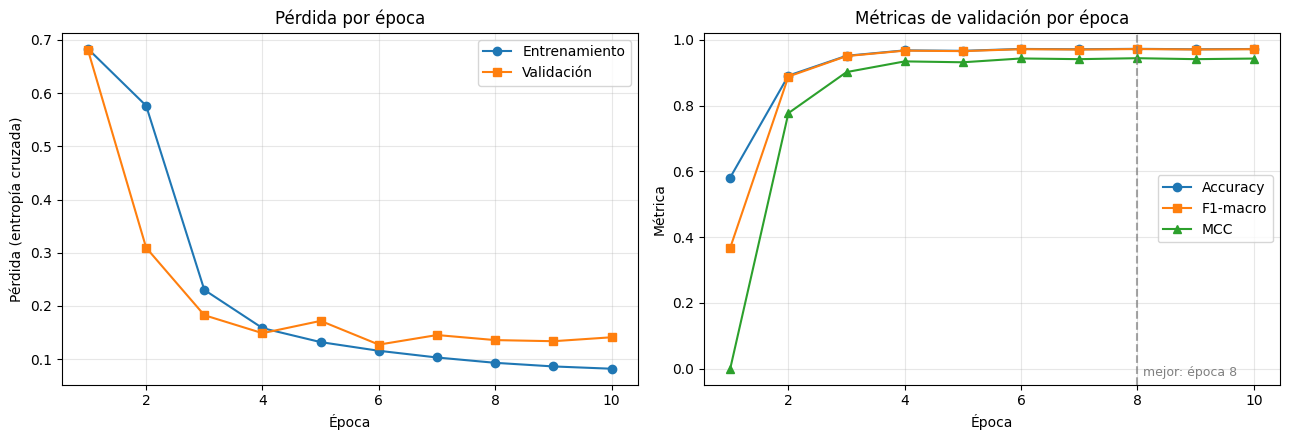

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(historial["epoca"], historial["train_loss"], marker="o", label="Entrenamiento")
axes[0].plot(historial["epoca"], historial["val_loss"], marker="s", label="Validación")
axes[0].set_xlabel("Época"); axes[0].set_ylabel("Pérdida (entropía cruzada)")
axes[0].set_title("Pérdida por época"); axes[0].legend(); axes[0].grid(alpha=.3)

axes[1].plot(historial["epoca"], historial["val_accuracy"], marker="o", label="Accuracy")
axes[1].plot(historial["epoca"], historial["val_f1_macro"], marker="s", label="F1-macro")
axes[1].plot(historial["epoca"], historial["val_mcc"], marker="^", label="MCC")
axes[1].axvline(mejor_epoca, ls="--", c="gray", alpha=.7)
axes[1].annotate(f"mejor: época {mejor_epoca}", xy=(mejor_epoca, axes[1].get_ylim()[0]),
                 xytext=(4, 6), textcoords="offset points", fontsize=9, color="gray")
axes[1].set_xlabel("Época"); axes[1].set_ylabel("Métrica")
axes[1].set_title("Métricas de validación por época"); axes[1].legend(); axes[1].grid(alpha=.3)

plt.tight_layout()
plt.savefig(os.path.join(DIR_SALIDA, "curvas_entrenamiento.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## §15 · Evaluación final sobre el conjunto de prueba

**Este es el único número reportable.** El conjunto de prueba no participó en el entrenamiento ni
en la elección del checkpoint ni en el ajuste de hiperparámetros.

Se compara contra las líneas de referencia triviales calculadas en la §8. Si el modelo no supera
claramente el piso de la clase mayoritaria, la conclusión es que la profundidad no se justificó.

In [ ]:
m_test, y_true, y_pred, probs, test_loss = evaluar(modelo, dl_test, CONFIG)

print("=" * 66)
print("RESULTADOS SOBRE EL CONJUNTO DE PRUEBA")
print("=" * 66)
print(f"Modelo    : {CONFIG['modelo']}")
print(f"Partición : {CONFIG['estrategia_particion']} {CONFIG['proporciones']}  |  semilla {SEED}")
print(f"n_test    : {len(y_true):,}   |   pérdida: {test_loss:.4f}")
print("-" * 66)
print(f"  Accuracy         : {m_test['accuracy']:.4f}")
print(f"  F1-macro         : {m_test['f1_macro']:.4f}   ← métrica principal")
print(f"  MCC (Matthews)   : {m_test['mcc']:.4f}")
print("-" * 66)
print("  Detección de noticia FALSA (positivo = label 0):")
print(f"    Precision      : {m_test['precision_falsa']:.4f}")
print(f"    Recall         : {m_test['recall_falsa']:.4f}")
print(f"    F1             : {m_test['f1_falsa']:.4f}")
print("  Convención del paper (positivo = label 1, noticia REAL):")
print(f"    Precision      : {m_test['precision_real']:.4f}")
print(f"    Recall         : {m_test['recall_real']:.4f}")
print(f"    F1             : {m_test['f1_real']:.4f}")
print("-" * 66)

piso = pd.Series(y_true).value_counts(normalize=True).max()
delta = m_test["accuracy"] - piso
print(f"  Clase mayoritaria (piso trivial): {piso:.4f}")
print(f"  Mejora del modelo sobre el piso : {delta:+.4f}  ({delta*100:+.2f} puntos)")
print("=" * 66)

print("\nReporte por clase (sklearn):\n")
print(classification_report(
    y_true, y_pred,
    target_names=[CONFIG["etiquetas"]["0"], CONFIG["etiquetas"]["1"]],
    digits=4, zero_division=0,
))

RESULTADOS SOBRE EL CONJUNTO DE PRUEBA
Modelo    : IsGarrido/roberta-base-bne
Partición : grupo [0.8, 0.1, 0.1]  |  semilla 16
n_test    : 5,728   |   pérdida: 0.1063
------------------------------------------------------------------
  Accuracy         : 0.9777
  F1-macro         : 0.9770   ← métrica principal
  MCC (Matthews)   : 0.9540
------------------------------------------------------------------
  Detección de noticia FALSA (positivo = label 0):
    Precision      : 0.9792
    Recall         : 0.9668
    F1             : 0.9730
  Convención del paper (positivo = label 1, noticia REAL):
    Precision      : 0.9766
    Recall         : 0.9854
    F1             : 0.9810
------------------------------------------------------------------
  Clase mayoritaria (piso trivial): 0.5841
  Mejora del modelo sobre el piso : +0.3936  (+39.36 puntos)

Reporte por clase (sklearn):

              precision    recall  f1-score   support

       falsa     0.9792    0.9668    0.9730      2382
    

---
## §16 · Matriz de confusión

Las cuatro celdas y qué significa cada una en este problema:

- **Falsa → Falsa**: desinformación detectada correctamente.
- **Real → Real**: noticia verdadera reconocida correctamente.
- **Falsa → Real** (*falso negativo* de detección): desinformación que pasa el filtro. El costo es
  que el sistema no sirvió para nada en ese caso.
- **Real → Falsa** (*falso positivo* de detección): una noticia verdadera marcada como falsa. El
  costo aquí es distinto y más delicado: es censura de información legítima.

**Esa asimetría hay que discutirla explícitamente en el informe** — es una de las preguntas de
sustentación.

Matriz de confusión (conteos):

             pred: falsa  pred: real
real: falsa         2303          79
real: real            49        3297

Normalizada por fila (% de cada clase verdadera):

             pred: falsa  pred: real
real: falsa        96.68        3.32
real: real          1.46       98.54


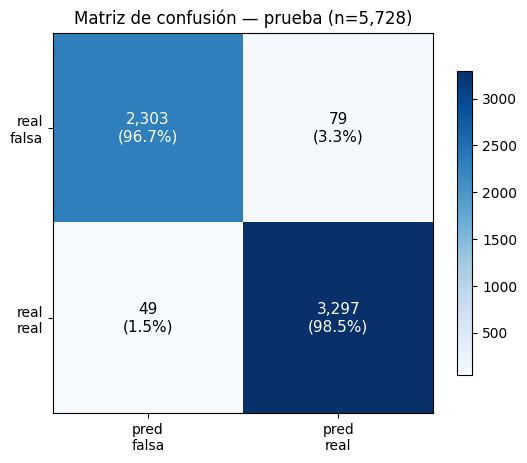

In [ ]:
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
nombres = [CONFIG["etiquetas"]["0"], CONFIG["etiquetas"]["1"]]

df_cm = pd.DataFrame(cm,
                     index=[f"real: {n}" for n in nombres],
                     columns=[f"pred: {n}" for n in nombres])
print("Matriz de confusión (conteos):\n")
print(df_cm.to_string())
print("\nNormalizada por fila (% de cada clase verdadera):\n")
print((df_cm.div(df_cm.sum(axis=1), axis=0) * 100).round(2).to_string())

fig, ax = plt.subplots(figsize=(5.5, 4.6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1], [f"pred\n{n}" for n in nombres])
ax.set_yticks([0, 1], [f"real\n{n}" for n in nombres])
umbral = cm.max() / 2
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i,j]:,}\n({cm[i,j]/cm[i].sum()*100:.1f}%)",
                ha="center", va="center", fontsize=11,
                color="white" if cm[i, j] > umbral else "black")
ax.set_title(f"Matriz de confusión — prueba (n={len(y_true):,})")
plt.colorbar(im, ax=ax, shrink=.8)
plt.tight_layout()
plt.savefig(os.path.join(DIR_SALIDA, "matriz_confusion.png"), dpi=150, bbox_inches="tight")
plt.show()

df_cm.to_csv(os.path.join(DIR_SALIDA, "matriz_confusion.csv"))

---
## §17 · Guardado de artefactos reproducibles

Todo lo que un tercero necesita para reejecutar esta corrida y obtener lo mismo:

- **`hiperparametros.json`** — configuración completa, versiones de librerías, GPU usada, hash MD5
  del CSV de entrada (verifica que sea el mismo archivo) y tamaño de cada split.
- **`particion.csv`** — qué fila fue a qué split. Auditable: cualquiera puede verificar que no hubo
  fuga.
- **`metricas_por_epoca.csv`** — la evidencia de las curvas.
- **`metricas_finales.json`** — el resultado reportable.
- **`predicciones_test.csv`** — predicción y probabilidad de cada noticia de prueba. **Es el insumo
  directo del análisis de fallas de la Fase 3**: permite filtrar los casos en que el modelo se
  equivocó y buscar qué tienen en común.
- **`modelo_baseline/`** — pesos y tokenizador, para recargar sin reentrenar.

In [ ]:
def md5_archivo(ruta, bloque=1 << 20):
    h = hashlib.md5()
    with open(ruta, "rb") as f:
        for chunk in iter(lambda: f.read(bloque), b""):
            h.update(chunk)
    return h.hexdigest()


registro = {
    "descripcion": "Baseline — fine-tuning directo de RoBERTa-BNE para clasificación binaria real/falsa",
    "timestamp_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "configuracion": CONFIG,
    "datos": {
        "archivo": RUTA_CSV,
        "md5": md5_archivo(RUTA_CSV),
        "n_total": int(len(df)),
        "n_train": int((df["split"] == "train").sum()),
        "n_val": int((df["split"] == "val").sum()),
        "n_test": int((df["split"] == "test").sum()),
        "n_grupos": int(df["grupo"].nunique()),
        "grupos_con_fuga": int(n_fuga),
        "distribucion_etiquetas": {str(k): int(v) for k, v in df[COL_LABEL].value_counts().items()},
        "pct_truncado_max_len": round(float(pct_trunc), 2),
    },
    "modelo_resuelto": {
        "repo": CONFIG["modelo"],
        "commit_sha": CONFIG.get("modelo_sha"),
        "es_repo_canonico_del_paper": CONFIG.get("modelo_es_canonico"),
        "repo_canonico": CONFIG["modelo_candidatos"][0],
    },
    "entrenamiento": {
        "mejor_epoca": int(mejor_epoca),
        "epocas_ejecutadas": int(len(historial)),
        "pasos_por_epoca": int(len(dl_train)),
        "parametros_entrenables": int(n_entrenables),
    },
    "entorno": {
        "python": platform.python_version(),
        "torch": torch.__version__,
        "transformers": transformers.__version__,
        "sklearn": sklearn.__version__,
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "dispositivo": str(DEVICE),
        "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    },
}

with open(os.path.join(DIR_SALIDA, "hiperparametros.json"), "w", encoding="utf-8") as f:
    json.dump(registro, f, indent=2, ensure_ascii=False, default=str)

resultados = {
    "metricas_test": m_test,
    "perdida_test": round(test_loss, 4),
    "n_test": int(len(y_true)),
    "linea_referencia_clase_mayoritaria": round(float(piso), 4),
    "mejora_sobre_linea_referencia": round(float(delta), 4),
    "matriz_confusion": {"orden_etiquetas": [0, 1], "matriz": cm.tolist()},
    "mejores_metricas_validacion": historial.loc[historial["epoca"] == mejor_epoca].to_dict("records")[0],
}
with open(os.path.join(DIR_SALIDA, "metricas_finales.json"), "w", encoding="utf-8") as f:
    json.dump(resultados, f, indent=2, ensure_ascii=False, default=str)

# Predicciones fila a fila, para el análisis de fallas de la Fase 3
sub_test = df[df["split"] == "test"].reset_index(drop=True)
pred_df = pd.DataFrame({
    "row_id": sub_test["row_id"].values,
    "label_real": y_true,
    "label_predicho": y_pred,
    "prob_falsa": probs[:, 0].round(4),
    "prob_real": probs[:, 1].round(4),
    "acierto": (y_true == y_pred),
    "titulo": sub_test[CONFIG["col_titulo"]].values,
    "descripcion": sub_test[CONFIG["col_descripcion"]].values,
})
if CONFIG["col_fecha"] in sub_test.columns:
    pred_df["fecha"] = sub_test[CONFIG["col_fecha"]].values
pred_df.to_csv(os.path.join(DIR_SALIDA, "predicciones_test.csv"), index=False)

if CONFIG["guardar_modelo"]:
    ruta_modelo = os.path.join(DIR_SALIDA, "modelo_baseline")
    modelo.save_pretrained(ruta_modelo)
    tokenizer.save_pretrained(ruta_modelo)
    print(f"✓ Modelo guardado en ./{ruta_modelo}/")

print(f"\nArtefactos en ./{DIR_SALIDA}/:")
for f_ in sorted(os.listdir(DIR_SALIDA)):
    ruta = os.path.join(DIR_SALIDA, f_)
    tam = os.path.getsize(ruta) if os.path.isfile(ruta) else sum(
        os.path.getsize(os.path.join(ruta, x)) for x in os.listdir(ruta))
    print(f"  {f_:<32} {tam/1024:>10,.1f} KB")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Modelo guardado en ./resultados_baseline_roberta_bne/modelo_baseline/

Artefactos en ./resultados_baseline_roberta_bne/:
  curvas_entrenamiento.png              102.9 KB
  dummy_noticias.csv                    110.0 KB
  hiperparametros.json                    2.5 KB
  matriz_confusion.csv                    0.1 KB
  matriz_confusion.png                   44.2 KB
  metricas_finales.json                   1.1 KB
  metricas_por_epoca.csv                  1.3 KB
  modelo_baseline                   490,495.5 KB
  particion.csv                       1,066.1 KB
  predicciones_test.csv               2,068.2 KB
  resumen_particion.csv                   0.2 KB


---
## §18 · Resumen para el informe

Genera el bloque de texto con todo lo que la rúbrica pide declarar explícitamente. Cópienlo tal
cual a la sección de metodología.

In [ ]:
resumen = f"""
CONFIGURACIÓN DEL BASELINE
==========================================================================
Modelo              : {CONFIG['modelo']} (preentrenado, sin adaptación adicional)
Commit del modelo   : {CONFIG.get('modelo_sha')}
¿Repo del paper?    : {'sí' if CONFIG.get('modelo_es_canonico') else 'NO — el repo canónico fue deprecado y vaciado'}
Estrategia          : ajuste fino completo — ninguna capa congelada
Tarea               : clasificación binaria (0 = falsa, 1 = real)

DATOS
--------------------------------------------------------------------------
Archivo             : {RUTA_CSV}
MD5                 : {registro['datos']['md5']}
Total de noticias   : {len(df):,}
Distribución        : {dict(df[COL_LABEL].value_counts().sort_index())}
Truncadas a {CONFIG['max_seq_length']} tok : {pct_trunc:.2f}%

PARTICIÓN
--------------------------------------------------------------------------
Estrategia          : {CONFIG['estrategia_particion']}
Proporciones        : {CONFIG['proporciones'][0]:.0%} / {CONFIG['proporciones'][1]:.0%} / {CONFIG['proporciones'][2]:.0%}
Tamaños             : train {registro['datos']['n_train']:,} · val {registro['datos']['n_val']:,} · test {registro['datos']['n_test']:,}
Agrupación variantes: {CONFIG['agrupar_variantes']} ({registro['datos']['n_grupos']:,} grupos)
Grupos con fuga     : {n_fuga}

HIPERPARÁMETROS
--------------------------------------------------------------------------
Semilla             : {CONFIG['seed']}
Épocas (máx / ejec.): {CONFIG['epocas']} / {len(historial)}   ·   mejor época: {mejor_epoca}
Learning rate       : {CONFIG['learning_rate']}   (AdamW, warmup {CONFIG['warmup_ratio']:.0%}, decaimiento lineal)
Batch size          : {CONFIG['batch_size']}
Max sequence length : {CONFIG['max_seq_length']}
Dropout             : {CONFIG['dropout']}
Weight decay (L2)   : {CONFIG['weight_decay']}
Recorte de gradiente: {CONFIG['max_grad_norm']}
Precisión mixta     : {CONFIG['usar_amp']}
Criterio de parada  : mejor {CONFIG['metrica_seleccion']} en validación, paciencia {CONFIG['paciencia']}

RESULTADOS SOBRE PRUEBA (n = {len(y_true):,})
--------------------------------------------------------------------------
Accuracy            : {m_test['accuracy']:.4f}
F1-macro            : {m_test['f1_macro']:.4f}   ← métrica principal
MCC                 : {m_test['mcc']:.4f}
Precision (falsa)   : {m_test['precision_falsa']:.4f}
Recall (falsa)      : {m_test['recall_falsa']:.4f}
F1 (falsa)          : {m_test['f1_falsa']:.4f}

Línea de referencia trivial (clase mayoritaria) : {piso:.4f}
Mejora sobre esa referencia                     : {delta:+.4f} ({delta*100:+.2f} pts)

ENTORNO
--------------------------------------------------------------------------
Python {registro['entorno']['python']} · torch {registro['entorno']['torch']} · transformers {registro['entorno']['transformers']} · sklearn {registro['entorno']['sklearn']}
Dispositivo: {registro['entorno']['dispositivo']} ({registro['entorno']['gpu']})
==========================================================================
"""
print(resumen)

with open(os.path.join(DIR_SALIDA, "resumen_informe.txt"), "w", encoding="utf-8") as f:
    f.write(resumen)
print(f"✓ Guardado en ./{DIR_SALIDA}/resumen_informe.txt")


CONFIGURACIÓN DEL BASELINE
Modelo              : IsGarrido/roberta-base-bne (preentrenado, sin adaptación adicional)
Commit del modelo   : 3d54a71ddc029cc1f8dd604e3b7bc0da0e2f7cd9
¿Repo del paper?    : NO — el repo canónico fue deprecado y vaciado
Estrategia          : ajuste fino completo — ninguna capa congelada
Tarea               : clasificación binaria (0 = falsa, 1 = real)

DATOS
--------------------------------------------------------------------------
Archivo             : noticias_filtradas.csv
MD5                 : 3813fa6e01c6c736092f15a5f0bd1641
Total de noticias   : 56,765
Distribución        : {0: np.int64(23851), 1: np.int64(32914)}
Truncadas a 128 tok : 0.70%

PARTICIÓN
--------------------------------------------------------------------------
Estrategia          : grupo
Proporciones        : 80% / 10% / 10%
Tamaños             : train 45,347 · val 5,690 · test 5,728
Agrupación variantes: True (44,394 grupos)
Grupos con fuga     : 0

HIPERPARÁMETROS
-------------------

# Línea base clásica — TF-IDF + clasificadores lineales

**Proyecto Integrador de Deep Learning · Primera entrega**
Angie Valentina Donato Pita · Miguel Ángel Amézquita Briceño · Lis Alejandra Sánchez Moreno

Artículo de referencia: Blanco-Fernández et al. (2024), *Enhancing Misinformation Detection in
Spanish Language with Deep Learning: BERT and RoBERTa Transformer Models*, Applied Sciences 14(21):9729.

---

## Qué es este notebook y por qué existe

En la guía del profesor, **«línea base» significa un modelo clásico sencillo** contra el cual medir
la mejora que aporta la arquitectura profunda. El notebook `V2_baseline_roberta_bne.ipynb` entrena
el modelo profundo; **este entrena la línea base de verdad**.

Sin este notebook, el 0,9777 de RoBERTa-BNE no se puede interpretar. Lo único con lo que se podía
comparar era el piso trivial de 58,41% (responder «real» siempre), y superar eso no demuestra nada.
La pregunta que importa es otra: **¿cuánto de ese 0,9777 lo consigue ya una bolsa de palabras con
regresión logística, que se entrena en segundos y no necesita GPU?**

Los trabajos citados en la Tabla 7 del artículo obtienen entre 74% y 81% con técnicas clásicas.
Ese es el orden de magnitud esperable, pero sobre *otros* corpus: el número que vale para el informe
es el que salga aquí, sobre **el mismo corpus y la misma partición**.

## La regla que hace válida la comparación

Este notebook **no vuelve a particionar nada**. Lee `particion.csv`, el archivo que V2 guardó
justamente para esto, y respeta fila por fila la asignación a train / validación / prueba.

Si cada notebook hiciera su propia partición, cualquier diferencia entre los dos modelos podría
venir de que les tocaron datos distintos, y la comparación no diría nada.

## El segundo uso: sonda del atajo

Hay una razón adicional, y para el informe es más interesante que el número.

La regresión logística sobre TF-IDF es **directamente interpretable**: cada término del vocabulario
tiene un coeficiente que dice cuánto empuja hacia «falsa» o hacia «real». Eso permite mirar de
frente la hipótesis del **confusor de origen** que planteamos en la lectura crítica.

Si los términos que más predicen «falsa» son **temáticos** (nombres propios, partidos, lugares),
el modelo está aprendiendo de qué se habla. Si son **estilísticos** (conectores, muletillas,
construcciones típicas de texto generado), el modelo está detectando *quién escribió el texto*,
no si el texto es cierto. La §11 pone esa lista sobre la mesa.

## Qué produce

- Métricas de tres clasificadores clásicos sobre exactamente la misma partición que V2.
- Una tabla comparativa directa contra el modelo profundo.
- La lista de términos más indicativos de cada clase.
- `predicciones_test_clasico.csv`, para el análisis de fallas de la Entrega Final.
- Un análisis de **concordancia** entre el modelo clásico y el profundo: en qué ejemplos coinciden
  y en cuáles no. Esto responde a la pregunta de si el modelo profundo aporta algo cualitativamente
  distinto o solo afina lo mismo.

## Requisitos

Necesita dos archivos de la corrida de V2:

| Archivo | Para qué | Obligatorio |
|---|---|---|
| `particion.csv` | Reproducir la misma partición | Sí |
| `predicciones_test.csv` | Comparar aciertos y fallos con el modelo profundo | No (la §12 se salta si falta) |

Y el CSV del corpus, el mismo que usó V2.

Corre en CPU. No necesita GPU.

---
## §1 · Importaciones

Mucho más ligero que V2: aquí no hay PyTorch ni Transformers. Todo es scikit-learn.

In [ ]:
import os
import re
import json
import time
import random
import hashlib
import platform
import unicodedata
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
)

print("numpy        :", np.__version__)
print("pandas       :", pd.__version__)
print("scikit-learn :", sklearn.__version__)

numpy        : 2.1.3
pandas       : 2.2.3
scikit-learn : 1.6.1


---
## §2 · Configuración

Igual que en V2, esta es la única celda que se toca al cambiar de corpus.

Ojo con `dir_v2`: tiene que apuntar a la carpeta donde V2 dejó `particion.csv`. Si corrieron V2 en
otra sesión de Colab, súbanla o móntenla desde Drive antes de seguir.

In [ ]:
CONFIG = {
    # ---------- DATOS ----------
    # El MISMO CSV que usó V2. Si no es el mismo, los row_id no coincidirán y la §4 lo detectará.
    "ruta_csv": "noticias_filtradas.csv",

    # Carpeta donde V2 dejó sus artefactos.
    "dir_v2": "resultados_baseline_roberta_bne",

    # Nombres de columna. Deben ser IDÉNTICOS a los que se usaron en V2.
    "col_label": "Label",
    "col_titulo": "Titulo",
    "col_descripcion": "Descripcion",
    "col_fecha": "Fecha",
    "fecha_dayfirst": False,
    "campos_texto": ["Titulo", "Descripcion"],
    "etiquetas": {"0": "falsa", "1": "real"},

    # ---------- VECTORIZACIÓN ----------
    # Rejilla de búsqueda. Se explora sobre VALIDACIÓN, nunca sobre prueba.
    "grid_ngramas": [(1, 1), (1, 2)],     # solo palabras | palabras + bigramas
    "grid_min_df": [2, 5],                # descartar términos que aparecen en menos de N documentos
    "grid_C": [0.1, 1.0, 10.0],           # inverso de la regularización
    "max_features": 300_000,              # techo del vocabulario, para acotar memoria
    "sublinear_tf": True,                 # usar 1+log(tf) en vez de tf; estándar en clasificación de texto

    # ---------- MÉTRICA Y SEMILLA ----------
    "seed": 16,                            # la misma que V2
    "metrica_seleccion": "f1_macro",       # el mismo criterio que V2

    # ---------- SALIDA ----------
    "dir_salida": "resultados_baseline_clasico",
}

SEED = CONFIG["seed"]
DIR_SALIDA = CONFIG["dir_salida"]
DIR_V2 = CONFIG["dir_v2"]
COL_LABEL = CONFIG["col_label"]
os.makedirs(DIR_SALIDA, exist_ok=True)

print(f"Corpus        : {CONFIG['ruta_csv']}")
print(f"Partición de  : ./{DIR_V2}/particion.csv")
print(f"Salidas en    : ./{DIR_SALIDA}/")

Corpus        : noticias_filtradas.csv
Partición de  : ./resultados_baseline_roberta_bne/particion.csv
Salidas en    : ./resultados_baseline_clasico/


---
## §3 · Reproducibilidad

Menos fuentes de aleatoriedad que en V2 (no hay GPU ni inicialización de pesos), pero se fijan
igual. `LogisticRegression` y `LinearSVC` reciben además `random_state` explícito más abajo.

In [ ]:
def fijar_semillas(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)


fijar_semillas(SEED)
print(f"Semilla fijada en {SEED}.")

Semilla fijada en 16.


---
## §4 · Reconstruir el corpus y aplicar la partición de V2

### El punto delicado

`particion.csv` guarda `row_id → split`, pero **no guarda el texto**. Así que hay que regenerar el
corpus con exactamente la misma limpieza que hizo V2, para que los `row_id` vuelvan a caer en las
mismas filas.

La función `cargar_y_limpiar` de abajo es **copia literal** de la §5 de V2. No la modifiquen: si
cambia una sola línea (el orden del dedup, el criterio de descarte), los `row_id` se desplazan y
la partición se aplica a las filas equivocadas — en silencio.

### Cómo se detecta si algo salió mal

La verificación de esta sección no se limita a comprobar que coincida el número de filas. Compara
**la etiqueta de cada `row_id`** entre el corpus regenerado y `particion.csv`. Si una sola no
coincide, aborta. Es el único modo de garantizar que estamos comparando lo mismo.

In [ ]:
def cargar_y_limpiar(ruta, cfg):
    """Copia literal de la §5 de V2. NO MODIFICAR."""
    col_l, col_t = cfg["col_label"], cfg["col_titulo"]
    col_d, col_f = cfg["col_descripcion"], cfg["col_fecha"]

    df = pd.read_csv(ruta)
    print(f"Filas leídas del CSV: {len(df):,}")

    faltantes = {col_l, col_t, col_d} - set(df.columns)
    if faltantes:
        raise ValueError(f"El CSV no tiene las columnas requeridas: {faltantes}. "
                         f"Columnas encontradas: {df.columns.tolist()}")

    df = df.copy()
    for c in [col_t, col_d]:
        df[c] = df[c].fillna("").astype(str).str.strip()

    partes = [df[c] for c in cfg["campos_texto"] if c in df.columns]
    df["texto"] = partes[0]
    for p in partes[1:]:
        df["texto"] = (df["texto"] + ". " + p).str.replace(r"\.\s*\.", ".", regex=True)
    df["texto"] = df["texto"].str.strip()

    n0 = len(df)
    df = df[df["texto"].str.len() > 0]

    df[col_l] = pd.to_numeric(df[col_l], errors="coerce")
    df = df[df[col_l].isin([0, 1])]
    df[col_l] = df[col_l].astype(int)
    print(f"Descartadas por texto vacío o etiqueta inválida: {n0 - len(df):,}")

    if col_f in df.columns:
        try:
            df[col_f] = pd.to_datetime(df[col_f], errors="coerce",
                                       format="mixed", dayfirst=cfg["fecha_dayfirst"])
        except (ValueError, TypeError):
            df[col_f] = pd.to_datetime(df[col_f], errors="coerce",
                                       dayfirst=cfg["fecha_dayfirst"])

    n1 = len(df)
    df = df.drop_duplicates(subset=[col_t, col_d, col_l])
    print(f"Duplicados exactos eliminados: {n1 - len(df):,}")

    df = df.reset_index(drop=True)
    df.insert(0, "row_id", np.arange(len(df)))
    return df


df = cargar_y_limpiar(CONFIG["ruta_csv"], CONFIG)
print(f"Corpus regenerado: {len(df):,} noticias\n")

# --- Cargar la partición de V2 ---
ruta_particion = os.path.join(DIR_V2, "particion.csv")
if not os.path.exists(ruta_particion):
    raise FileNotFoundError(
        f"No se encontró '{ruta_particion}'.\n"
        "Este notebook NO debe particionar por su cuenta: la comparación con el modelo profundo\n"
        "solo es válida si ambos usan la misma partición.\n"
        "Corran primero V2_baseline_roberta_bne.ipynb, o suban su carpeta de resultados."
    )

part = pd.read_csv(ruta_particion)
print(f"Partición leída: {len(part):,} filas · columnas {part.columns.tolist()}")

Filas leídas del CSV: 57,231
Descartadas por texto vacío o etiqueta inválida: 0
Duplicados exactos eliminados: 466
Corpus regenerado: 56,765 noticias

Partición leída: 56,765 filas · columnas ['row_id', 'split', 'grupo', 'Label']


### Verificación de consistencia

Tres comprobaciones, de la más barata a la más estricta. Si alguna falla, el notebook se detiene:
es preferible parar aquí a producir una comparación inválida sin avisar.

In [ ]:
problemas = []

# 1. Mismo número de filas
if len(part) != len(df):
    problemas.append(f"Distinto número de filas: partición {len(part):,} vs corpus {len(df):,}")

# 2. Mismos row_id
if not problemas:
    if set(part["row_id"]) != set(df["row_id"]):
        problemas.append("Los conjuntos de row_id no coinciden.")

# 3. Misma etiqueta para cada row_id  ← la que de verdad importa
if not problemas:
    fusion = df[["row_id", COL_LABEL, "texto"]].merge(
        part[["row_id", "split", "grupo", COL_LABEL]],
        on="row_id", how="inner", suffixes=("_corpus", "_particion")
    )
    n_discrepantes = int((fusion[f"{COL_LABEL}_corpus"] != fusion[f"{COL_LABEL}_particion"]).sum())
    if n_discrepantes:
        problemas.append(f"{n_discrepantes:,} filas tienen etiqueta distinta entre corpus y partición.")

if problemas:
    print("❌ VERIFICACIÓN FALLIDA\n")
    for p in problemas:
        print(f"   · {p}")
    print("\nCausa habitual: el CSV no es el mismo que usó V2, o la función de limpieza cambió.")
    print("Comparar el MD5 del CSV contra el que V2 registró en 'hiperparametros.json'.")
    raise SystemExit("Partición incompatible con el corpus. Revisar antes de continuar.")

print("✓ Verificación superada: mismo número de filas, mismos row_id, misma etiqueta en todos.")

# Construir el dataframe de trabajo
df = fusion.rename(columns={f"{COL_LABEL}_corpus": COL_LABEL}).drop(columns=[f"{COL_LABEL}_particion"])
df = df.sort_values("row_id").reset_index(drop=True)

resumen = df.groupby("split").agg(
    n=("row_id", "size"),
    pct=("row_id", lambda s: round(len(s) / len(df) * 100, 2)),
    pct_real=(COL_LABEL, lambda s: round(s.mean() * 100, 2)),
).loc[[s for s in ["train", "val", "test"] if s in df["split"].unique()]]

print("\nPartición heredada de V2:\n")
print(resumen.to_string())

✓ Verificación superada: mismo número de filas, mismos row_id, misma etiqueta en todos.

Partición heredada de V2:

           n    pct  pct_real
split                        
train  45347  79.89     57.91
val     5690  10.02     58.15
test    5728  10.09     58.41


---
## §5 · Vectorización TF-IDF

### Qué hace TF-IDF

Convierte cada noticia en un vector con una posición por cada término del vocabulario. El valor de
cada posición combina dos cosas:

- **TF** (*term frequency*): cuántas veces aparece el término en ese documento.
- **IDF** (*inverse document frequency*): cuán raro es el término en todo el corpus.

Un término que sale en todos los documentos («de», «el») recibe IDF bajo y casi no pesa. Uno que
sale en pocos documentos recibe IDF alto y discrimina mucho. El resultado es una matriz enorme
pero **dispersa**: la mayoría de las posiciones son cero, porque una noticia usa unos pocos
cientos de términos de un vocabulario de cientos de miles.

`sublinear_tf=True` usa `1 + log(tf)` en lugar de `tf`. Evita que un término repetido diez veces
pese diez veces más que uno que aparece una vez; en clasificación de texto casi siempre ayuda.

### La diferencia de fondo con el modelo profundo

TF-IDF es una **bolsa de palabras**: pierde el orden. «El fiscal acusó al ministro» y «El ministro
acusó al fiscal» producen exactamente el mismo vector. Los bigramas recuperan algo de contexto
local, pero nada comparable a la atención de un Transformer.

Ahí está el interés de la comparación: **cuánto vale, en este corpus concreto, entender el orden
de las palabras**. Si la bolsa de palabras ya llega al 95%, la respuesta es «poco», y eso dice algo
incómodo sobre en qué se apoya el modelo profundo.

### El error que hay que evitar

`TfidfVectorizer` se ajusta **solo sobre entrenamiento**. Ajustarlo sobre todo el corpus es una
forma sutil de fuga: el vocabulario y las estadísticas IDF incorporarían información de los
documentos de prueba, y el modelo llegaría a la evaluación sabiendo algo que no debería.

Es un error frecuente porque no rompe nada ni da error — simplemente infla la métrica. Por eso
aquí `fit_transform` se llama sobre train y `transform` sobre validación y prueba.

In [ ]:
def separar_splits(df, col_label):
    out = {}
    for s in ["train", "val", "test"]:
        sub = df[df["split"] == s]
        out[s] = (sub["texto"].values, sub[col_label].values, sub["row_id"].values)
    return out


D = separar_splits(df, COL_LABEL)
X_txt_tr, y_tr, id_tr = D["train"]
X_txt_va, y_va, id_va = D["val"]
X_txt_te, y_te, id_te = D["test"]

print(f"train {len(y_tr):,} · val {len(y_va):,} · test {len(y_te):,}")


def vectorizar(ngramas, min_df, cfg, textos_train, *otros):
    """Ajusta el vectorizador SOLO en train y transforma el resto."""
    vec = TfidfVectorizer(
        ngram_range=ngramas,
        min_df=min_df,
        max_features=cfg["max_features"],
        sublinear_tf=cfg["sublinear_tf"],
        strip_accents="unicode",
        lowercase=True,
    )
    Xtr = vec.fit_transform(textos_train)          # fit SOLO aquí
    resto = [vec.transform(t) for t in otros]      # transform en el resto
    return vec, Xtr, resto


# Un ejemplo para ver el tamaño del problema
vec_demo, Xtr_demo, _ = vectorizar((1, 2), 2, CONFIG, X_txt_tr, X_txt_va)
densidad = Xtr_demo.nnz / (Xtr_demo.shape[0] * Xtr_demo.shape[1]) * 100
print(f"\nCon ngramas (1,2) y min_df=2:")
print(f"  Vocabulario     : {len(vec_demo.vocabulary_):,} términos")
print(f"  Matriz de train : {Xtr_demo.shape[0]:,} × {Xtr_demo.shape[1]:,}")
print(f"  Valores no nulos: {Xtr_demo.nnz:,}  (densidad {densidad:.4f}%)")
print(f"  Términos por noticia (media): {Xtr_demo.nnz / Xtr_demo.shape[0]:.0f}")
del vec_demo, Xtr_demo

train 45,347 · val 5,690 · test 5,728

Con ngramas (1,2) y min_df=2:
  Vocabulario     : 294,489 términos
  Matriz de train : 45,347 × 294,489
  Valores no nulos: 3,872,635  (densidad 0.0290%)
  Términos por noticia (media): 85


---
## §6 · Métricas

Copia literal de la §12 de V2, para que los números sean comparables sin asteriscos.

Se reportan las **dos convenciones de clase positiva**, porque el artículo y la tarea real no
coinciden:

- **`falsa` = positivo (label 0)**: es lo que interesa operativamente. El recall de esta clase
  responde a «de todas las noticias falsas, ¿cuántas detecté?».
- **`real` = positivo (label 1)**: es la convención del artículo. Se incluye solo para poder
  comparar cifras con la Tabla 5 sin traducir.

**MCC** es la métrica que no se deja engañar. Un clasificador que responde siempre lo mismo obtiene
MCC = 0 aunque su F1 sobre la clase mayoritaria parezca decente — exactamente lo que pasó en la
época 1 de V2, y lo que el artículo reporta para RoBERTa-multilingual sin ajuste fino.

In [ ]:
def calcular_metricas(y_true, y_pred, cfg):
    m = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred),
    }
    for etiqueta, nombre in cfg["etiquetas"].items():
        k = int(etiqueta)
        m[f"precision_{nombre}"] = precision_score(y_true, y_pred, pos_label=k, zero_division=0)
        m[f"recall_{nombre}"] = recall_score(y_true, y_pred, pos_label=k, zero_division=0)
        m[f"f1_{nombre}"] = f1_score(y_true, y_pred, pos_label=k, zero_division=0)
    return m


# Piso trivial sobre prueba: el número mínimo que hay que superar
prop_test = pd.Series(y_te).value_counts(normalize=True)
PISO_TRIVIAL = float(prop_test.max())
CLASE_MAYORITARIA = int(prop_test.idxmax())

print("Piso trivial sobre el conjunto de prueba")
print("-" * 46)
for k, v in prop_test.sort_index().items():
    print(f"  Responder siempre '{CONFIG['etiquetas'][str(k)]}': accuracy = {v*100:5.2f}%")
print(f"\n  → Piso a superar: {PISO_TRIVIAL*100:.2f}%  "
      f"(clase '{CONFIG['etiquetas'][str(CLASE_MAYORITARIA)]}')")

Piso trivial sobre el conjunto de prueba
----------------------------------------------
  Responder siempre 'falsa': accuracy = 41.59%
  Responder siempre 'real': accuracy = 58.41%

  → Piso a superar: 58.41%  (clase 'real')


---
## §7 · Los tres clasificadores

### Regresión logística

Aprende un peso por término y suma. El resultado pasa por una sigmoide que lo convierte en
probabilidad. Es el caballo de batalla de la clasificación de texto: rápido, estable y —lo que aquí
más importa— **interpretable**, porque cada peso se lee directamente como «cuánto empuja este
término hacia una clase u otra».

### SVM lineal

Busca el hiperplano que separa las clases con el mayor margen posible. En espacios de dimensión muy
alta y datos dispersos como TF-IDF suele rendir algo mejor que la regresión logística. La
contrapartida es que no produce probabilidades calibradas, solo distancias al hiperplano.

### Naive Bayes multinomial

Asume que los términos son independientes entre sí dada la clase. Es una suposición falsa —las
palabras de un texto están muy correlacionadas— pero funciona sorprendentemente bien y entrena en
un abrir y cerrar de ojos. Va incluido como referencia inferior: si un modelo elaborado no supera
a Naive Bayes, algo va mal.

### Sobre `class_weight`

Se deja en `None`, sin compensar el desbalance, porque el artículo tampoco lo hace y el objetivo es
comparar en igualdad de condiciones. El corpus está 58/42, un desbalance moderado. Probar
`class_weight="balanced"` es un experimento razonable para la Segunda entrega.

In [ ]:
def construir_clasificador(nombre, C, seed):
    if nombre == "logreg":
        return LogisticRegression(
            C=C, max_iter=2000, solver="liblinear", random_state=seed, class_weight=None,
        )
    if nombre == "svm":
        return LinearSVC(C=C, max_iter=5000, random_state=seed, class_weight=None)
    if nombre == "nb":
        return MultinomialNB(alpha=1.0)   # no usa C
    raise ValueError(f"Clasificador desconocido: {nombre}")


MODELOS = ["logreg", "svm", "nb"]
NOMBRES_LEGIBLES = {
    "logreg": "TF-IDF + Regresión logística",
    "svm": "TF-IDF + SVM lineal",
    "nb": "TF-IDF + Naive Bayes",
}
print("Clasificadores a evaluar:")
for m in MODELOS:
    print(f"  · {NOMBRES_LEGIBLES[m]}")

Clasificadores a evaluar:
  · TF-IDF + Regresión logística
  · TF-IDF + SVM lineal
  · TF-IDF + Naive Bayes


---
## §8 · Búsqueda de hiperparámetros sobre validación

### El protocolo

La rejilla se explora midiendo en **validación**. El conjunto de prueba no se toca hasta la §9, y
se toca una sola vez.

Esto no es formalismo. Si se ajustan hiperparámetros mirando la prueba, el número final deja de
estimar el rendimiento sobre datos nuevos y pasa a medir cuánto se optimizó contra ese conjunto
concreto. En la lectura crítica señalamos que el artículo es ambiguo justamente en este punto;
aquí queda explícito y auditable.

### Qué se explora

| Hiperparámetro | Valores | Qué controla |
|---|---|---|
| `ngram_range` | (1,1), (1,2) | Solo palabras, o palabras más bigramas |
| `min_df` | 2, 5 | Umbral para descartar términos poco frecuentes |
| `C` | 0,1 · 1 · 10 | Fuerza de la regularización (menor C = más regularización) |

Son 12 combinaciones para regresión logística, 12 para SVM y 4 para Naive Bayes (no usa `C`).
Como el vectorizador cambia con `ngram_range` y `min_df`, se reajusta en cada combinación —
siempre solo sobre train.

In [ ]:
t0 = time.time()
resultados_val = []

for ngramas in CONFIG["grid_ngramas"]:
    for min_df in CONFIG["grid_min_df"]:
        vec, Xtr, (Xva,) = vectorizar(ngramas, min_df, CONFIG, X_txt_tr, X_txt_va)
        n_vocab = len(vec.vocabulary_)

        for nombre in MODELOS:
            valores_C = CONFIG["grid_C"] if nombre != "nb" else [None]
            for C in valores_C:
                fijar_semillas(SEED)
                clf = construir_clasificador(nombre, C, SEED)
                clf.fit(Xtr, y_tr)
                pred_va = clf.predict(Xva)
                m = calcular_metricas(y_va, pred_va, CONFIG)
                resultados_val.append({
                    "modelo": nombre,
                    "ngramas": str(ngramas),
                    "min_df": min_df,
                    "C": C,
                    "n_vocab": n_vocab,
                    **{f"val_{k}": v for k, v in m.items()},
                })
        del vec, Xtr, Xva

tabla_val = pd.DataFrame(resultados_val)
print(f"Explorados {len(tabla_val)} ajustes en {time.time()-t0:.1f} s.\n")

crit = f"val_{CONFIG['metrica_seleccion']}"
mejores = {}
for nombre in MODELOS:
    sub = tabla_val[tabla_val["modelo"] == nombre].sort_values(crit, ascending=False)
    mejores[nombre] = sub.iloc[0].to_dict()

print(f"Mejor ajuste de cada clasificador según {CONFIG['metrica_seleccion']} en VALIDACIÓN:\n")
cols = ["modelo", "ngramas", "min_df", "C", "n_vocab", crit, "val_accuracy", "val_mcc"]
print(pd.DataFrame([mejores[m] for m in MODELOS])[cols].to_string(index=False))

tabla_val.to_csv(os.path.join(DIR_SALIDA, "busqueda_validacion.csv"), index=False)
print(f"\n✓ Rejilla completa guardada en ./{DIR_SALIDA}/busqueda_validacion.csv")

Explorados 28 ajustes en 49.0 s.

Mejor ajuste de cada clasificador según f1_macro en VALIDACIÓN:

modelo ngramas  min_df    C  n_vocab  val_f1_macro  val_accuracy  val_mcc
logreg  (1, 2)       5 10.0    77080      0.937202      0.939719 0.877199
   svm  (1, 2)       2 10.0   294489      0.943658      0.945518 0.888015
    nb  (1, 2)       5  NaN    77080      0.859873      0.870650 0.746218

✓ Rejilla completa guardada en ./resultados_baseline_clasico/busqueda_validacion.csv


### Cuánto importó cada hiperparámetro

Útil para el informe: si la métrica apenas se mueve con `C`, no vale la pena discutirlo; si se
mueve mucho con `ngram_range`, es que el contexto local sí aporta.

In [ ]:
print("Sensibilidad a cada hiperparámetro (media de "
      f"{CONFIG['metrica_seleccion']} en validación):\n")
for h in ["ngramas", "min_df", "C"]:
    sub = tabla_val[tabla_val["C"].notna()] if h == "C" else tabla_val
    g = sub.groupby(h)[crit].agg(["mean", "std", "max"]).round(4)
    print(f"  {h}:")
    print(g.to_string().replace("\n", "\n  "))
    print()

Sensibilidad a cada hiperparámetro (media de f1_macro en validación):

  ngramas:
           mean     std     max
  ngramas                        
  (1, 1)   0.8888  0.0346  0.9226
  (1, 2)   0.8923  0.0590  0.9437

  min_df:
          mean     std     max
  min_df                        
  2       0.8843  0.0560  0.9437
  5       0.8967  0.0383  0.9403

  C:
        mean     std     max
  C                           
  0.1   0.8675  0.0405  0.9090
  1.0   0.9175  0.0149  0.9403
  10.0  0.9221  0.0196  0.9437



---
## §9 · Evaluación final sobre prueba

Se reentrena cada clasificador con su mejor configuración y se evalúa **una sola vez** sobre el
conjunto de prueba.

Nota sobre el entrenamiento final: se usa solo `train`, no `train + val`. Juntarlos daría un modelo
algo mejor, pero rompería la comparación con V2, que también entrenó solo con `train`. La igualdad
de condiciones vale más que el punto extra.

In [ ]:
metricas_test = {}
predicciones = {}
modelos_entrenados = {}
vectorizadores = {}

for nombre in MODELOS:
    cfg_m = mejores[nombre]
    ngramas = eval(cfg_m["ngramas"])
    min_df = int(cfg_m["min_df"])
    C = cfg_m["C"]

    vec, Xtr, (Xte,) = vectorizar(ngramas, min_df, CONFIG, X_txt_tr, X_txt_te)
    fijar_semillas(SEED)
    clf = construir_clasificador(nombre, C, SEED)
    clf.fit(Xtr, y_tr)

    pred_te = clf.predict(Xte)
    if hasattr(clf, "predict_proba"):
        score = clf.predict_proba(Xte)[:, 1]
    else:
        score = clf.decision_function(Xte)

    metricas_test[nombre] = calcular_metricas(y_te, pred_te, CONFIG)
    predicciones[nombre] = {"pred": pred_te, "score": score}
    modelos_entrenados[nombre] = clf
    vectorizadores[nombre] = vec

print("=" * 74)
print("RESULTADOS SOBRE EL CONJUNTO DE PRUEBA")
print("=" * 74)
print(f"n_test: {len(y_te):,}   ·   piso trivial: {PISO_TRIVIAL:.4f}\n")

filas = []
for nombre in MODELOS:
    m = metricas_test[nombre]
    filas.append({
        "clasificador": NOMBRES_LEGIBLES[nombre],
        "accuracy": round(m["accuracy"], 4),
        "f1_macro": round(m["f1_macro"], 4),
        "mcc": round(m["mcc"], 4),
        "recall_falsa": round(m["recall_falsa"], 4),
        "precision_falsa": round(m["precision_falsa"], 4),
        "sobre_piso": f"+{(m['accuracy'] - PISO_TRIVIAL)*100:.2f} pts",
    })
tabla_test = pd.DataFrame(filas)
print(tabla_test.to_string(index=False))

mejor_clasico = max(MODELOS, key=lambda n: metricas_test[n][CONFIG["metrica_seleccion"]])
print(f"\n→ Mejor línea base clásica: {NOMBRES_LEGIBLES[mejor_clasico]}")
print(f"  {CONFIG['metrica_seleccion']} = {metricas_test[mejor_clasico][CONFIG['metrica_seleccion']]:.4f}")

print(f"\n\nReporte por clase del mejor clasificador ({NOMBRES_LEGIBLES[mejor_clasico]}):\n")
print(classification_report(
    y_te, predicciones[mejor_clasico]["pred"],
    target_names=[CONFIG["etiquetas"]["0"], CONFIG["etiquetas"]["1"]],
    digits=4, zero_division=0,
))

RESULTADOS SOBRE EL CONJUNTO DE PRUEBA
n_test: 5,728   ·   piso trivial: 0.5841

                clasificador  accuracy  f1_macro    mcc  recall_falsa  precision_falsa sobre_piso
TF-IDF + Regresión logística    0.9412    0.9386 0.8800        0.8841           0.9719 +35.70 pts
         TF-IDF + SVM lineal    0.9494    0.9475 0.8958        0.9173           0.9592 +36.52 pts
        TF-IDF + Naive Bayes    0.8684    0.8566 0.7416        0.7003           0.9766 +28.42 pts

→ Mejor línea base clásica: TF-IDF + SVM lineal
  f1_macro = 0.9475


Reporte por clase del mejor clasificador (TF-IDF + SVM lineal):

              precision    recall  f1-score   support

       falsa     0.9592    0.9173    0.9378      2382
        real     0.9429    0.9722    0.9573      3346

    accuracy                         0.9494      5728
   macro avg     0.9510    0.9448    0.9475      5728
weighted avg     0.9497    0.9494    0.9492      5728



---
## §10 · Matrices de confusión

Normalizadas por fila, para leer directamente el recall de cada clase. La diagonal es lo que se
acierta; fuera de la diagonal está el tipo de error.

En detección de desinformación los dos errores no cuestan lo mismo: dejar pasar una noticia falsa
como verdadera (fila «falsa», columna «real») es más grave que marcar una verdadera como falsa.

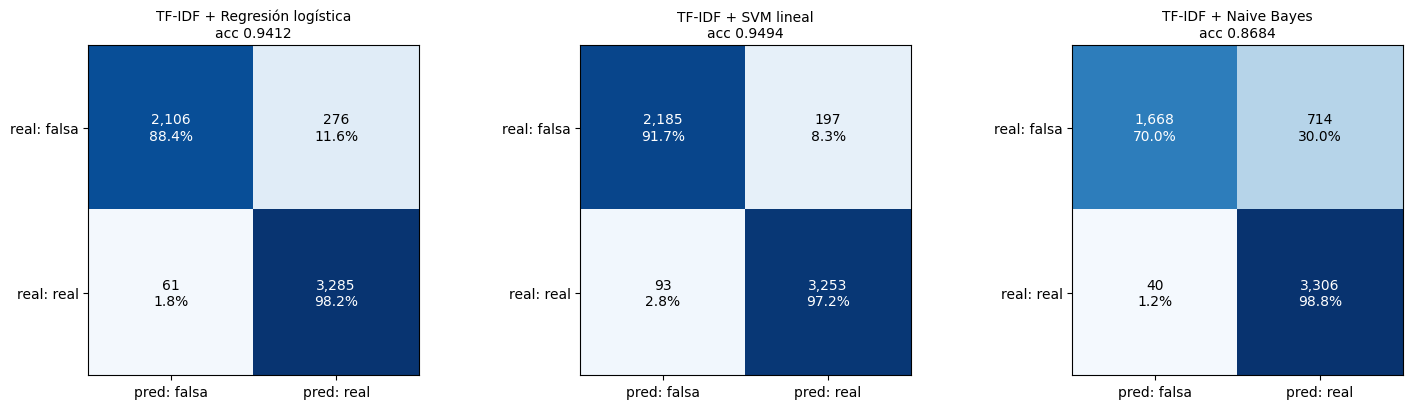

Matriz del mejor clasificador (TF-IDF + SVM lineal):

             pred: falsa  pred: real
real: falsa         2185         197
real: real            93        3253

  Falsas que se colaron como reales : 197
  Reales marcadas como falsas       : 93


In [ ]:
fig, axes = plt.subplots(1, len(MODELOS), figsize=(5 * len(MODELOS), 4.2))
if len(MODELOS) == 1:
    axes = [axes]
nombres_clase = [CONFIG["etiquetas"]["0"], CONFIG["etiquetas"]["1"]]

for ax, nombre in zip(axes, MODELOS):
    cm = confusion_matrix(y_te, predicciones[nombre]["pred"], labels=[0, 1])
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
    im = ax.imshow(cm_pct, cmap="Blues", vmin=0, vmax=100)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}\n{cm_pct[i, j]:.1f}%",
                    ha="center", va="center",
                    color="white" if cm_pct[i, j] > 55 else "black", fontsize=10)
    ax.set_xticks([0, 1]); ax.set_xticklabels([f"pred: {n}" for n in nombres_clase])
    ax.set_yticks([0, 1]); ax.set_yticklabels([f"real: {n}" for n in nombres_clase])
    ax.set_title(f"{NOMBRES_LEGIBLES[nombre]}\nacc {metricas_test[nombre]['accuracy']:.4f}",
                 fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(DIR_SALIDA, "matrices_confusion_clasicos.png"), dpi=140,
            bbox_inches="tight")
plt.show()

cm_mejor = confusion_matrix(y_te, predicciones[mejor_clasico]["pred"], labels=[0, 1])
print(f"Matriz del mejor clasificador ({NOMBRES_LEGIBLES[mejor_clasico]}):\n")
print(pd.DataFrame(cm_mejor,
                   index=[f"real: {n}" for n in nombres_clase],
                   columns=[f"pred: {n}" for n in nombres_clase]).to_string())
print(f"\n  Falsas que se colaron como reales : {cm_mejor[0, 1]:,}")
print(f"  Reales marcadas como falsas       : {cm_mejor[1, 0]:,}")

---
## §11 · Términos más indicativos — la sonda del atajo

### Por qué esta sección es la más importante del notebook

La regresión logística asigna un coeficiente a cada término. Positivo empuja hacia `real`,
negativo hacia `falsa`. Ordenar esos coeficientes da, literalmente, **la lista de palabras en las
que el modelo se apoya para decidir**.

Eso permite contrastar la hipótesis del confusor de origen sin necesidad de mapas de atención.
La pregunta a hacerle a la lista:

> ¿Estos términos hablan de **qué se dice**, o de **cómo está escrito**?

### Cómo leer el resultado

| Si los términos son… | Interpretación |
|---|---|
| **Nombres propios de personas y partidos**, repartidos de forma asimétrica entre las clases | Firma de la **Vía 4** del artículo: las falsas se fabricaron sustituyendo entidades con spaCy. El clasificador no juzga veracidad, reconoce **qué nombres aparecen**. Es el hallazgo más grave posible. |
| Conectores, adverbios, verbos genéricos, muletillas | El modelo detecta **registro de redacción**. Como parte de las falsas las generó GPT-3.5, esto sería la huella del generador. |
| Cifras, fechas, siglas, vocabulario institucional del lado «real» | Las verdaderas vienen de scraping y de la API del INE, y arrastran vocabulario que las falsas no tienen. Mismo problema por el otro lado. |
| Temas concretos, sin que domine ninguno de los tres patrones anteriores | El modelo aprende que ciertos asuntos aparecen más en desinformación. Discutible, pero al menos es señal sustantiva. |

### Lo que aparece de hecho en este corpus

Al ejecutarlo sobre el corpus español, la lista sale dominada por el **primer** patrón: el lado
«real» se llena de actores mayoritarios de la política española (PP, PSOE, Podemos, Sánchez,
Ayuso, Rajoy) y el lado «falsa» de partidos regionales pequeños y figuras de segunda línea (Equo,
BNG, EAJ-PNV, Coalición Canaria, Calviño, Narbona).

La lectura es directa: cuando el generador sustituye entidades, echa mano de un repertorio que
sobre-representa nombres que en las noticias reales aparecen poco. Basta con reconocer esos
nombres para clasificar. **No hay verificación de nada.**

Verifíquenlo en su propia corrida antes de escribirlo, y respáldenlo con la comprobación
cuantitativa de la celda siguiente.

### Advertencia sobre bigramas

Si el mejor ajuste usa `ngram_range=(1,2)`, la lista mezcla palabras sueltas y pares. No es un
problema, pero conviene notarlo al citarla.

In [ ]:
if "logreg" in modelos_entrenados:
    clf_lr = modelos_entrenados["logreg"]
    vec_lr = vectorizadores["logreg"]
    terminos = np.array(vec_lr.get_feature_names_out())
    coefs = clf_lr.coef_[0]

    TOP = 25
    idx_real = np.argsort(coefs)[-TOP:][::-1]      # coeficiente más positivo
    idx_falsa = np.argsort(coefs)[:TOP]            # coeficiente más negativo

    comp = pd.DataFrame({
        f"→ predice '{CONFIG['etiquetas']['1']}'": terminos[idx_real],
        "coef_real": np.round(coefs[idx_real], 3),
        f"→ predice '{CONFIG['etiquetas']['0']}'": terminos[idx_falsa],
        "coef_falsa": np.round(coefs[idx_falsa], 3),
    })

    print(f"Los {TOP} términos más indicativos de cada clase")
    print(f"(regresión logística, ngramas {mejores['logreg']['ngramas']}, "
          f"vocabulario {mejores['logreg']['n_vocab']:,})\n")
    print(comp.to_string(index=False))

    comp.to_csv(os.path.join(DIR_SALIDA, "terminos_indicativos.csv"), index=False)
    print(f"\n✓ Guardado en ./{DIR_SALIDA}/terminos_indicativos.csv")

    print("\n" + "─" * 74)
    print("PARA EL INFORME: clasifiquen a mano estos 50 términos en cuatro grupos —")
    print("  (a) entidades  : nombres de personas y de partidos")
    print("  (b) estilísticos: conectores, adverbios, verbos genéricos, muletillas")
    print("  (c) estructurales: cifras, fechas, siglas, vocabulario institucional")
    print("  (d) temáticos  : asuntos y materias concretas")
    print("\nSi domina (a), (b) o (c), el rendimiento viene del proceso que generó los")
    print("textos y no de su veracidad. La celda siguiente lo cuantifica.")
    print("─" * 74)
else:
    print("La regresión logística no está entre los modelos; se salta esta sección.")

Los 25 términos más indicativos de cada clase
(regresión logística, ngramas (1, 2), vocabulario 77,080)

→ predice 'real'  coef_real → predice 'falsa'  coef_falsa
         podemos     32.634              equo     -42.536
          del pp     28.372               bng     -27.572
         sanchez     27.334           calvino     -21.085
             erc     24.710  cristina narbona     -20.586
           el pp     24.329           narbona     -20.352
              iu     18.376           eaj pnv     -20.177
         el psoe     17.824               eaj     -20.177
           ayuso     16.672    nueva canarias     -18.966
       compromis     16.548 coalicion canaria     -18.958
        del psoe     15.931          gallardo     -17.502
        iglesias     13.570     jordi sevilla     -17.418
           al pp     13.028           canaria     -17.378
          casado     12.790           del bng     -16.569
           bildu     12.431     carlos prieto     -15.873
         montero     11.9

### Comprobación cuantitativa: ¿son términos exclusivos de una clase?

Los coeficientes por sí solos no cierran el argumento: un término puede tener peso alto y aun así
aparecer en ambas clases. Lo que delata la sustitución de entidades es la **asimetría de
aparición** — que un nombre salga casi solo en un lado.

Para cada uno de los términos más indicativos se calcula en qué porcentaje de las noticias de cada
clase aparece, sobre el conjunto de **entrenamiento**.

Cómo leerlo:

- **Ratio cercano a 1**: el término sale en ambas clases; el modelo lo usa por matices de
  frecuencia. Señal legítima aunque débil.
- **Ratio muy alto o muy bajo (>10× o <0,1×)**: el término es **prácticamente exclusivo** de una
  clase. Si además es un nombre propio, es una entidad sustituida: el modelo puede resolver el
  ejemplo con solo detectar ese nombre, sin leer nada más.

Un promedio alto de exclusividad es la evidencia dura para el informe.

In [ ]:
if "logreg" in modelos_entrenados:
    # Se recalcula la matriz de entrenamiento con el MISMO vectorizador ya ajustado.
    # Usar la matriz (y no buscar la subcadena en el texto crudo) garantiza que la
    # tokenización sea idéntica a la que vio el clasificador: mismas tildes, mismos
    # bigramas, mismos límites de palabra.
    Xtr_lr = vec_lr.transform(X_txt_tr)
    presencia = (Xtr_lr > 0)                      # matriz booleana documento × término
    mask_falsa = (y_tr == 0)
    mask_real = (y_tr == 1)
    n_falsa, n_real = int(mask_falsa.sum()), int(mask_real.sum())

    filas_exc = []
    for idx, lado in [(idx_falsa, "falsa"), (idx_real, "real")]:
        for i in idx[:15]:
            col = presencia[:, i]
            p_f = float(col[mask_falsa].sum()) / n_falsa * 100
            p_r = float(col[mask_real].sum()) / n_real * 100
            ratio = (p_f + 1e-6) / (p_r + 1e-6)
            filas_exc.append({
                "termino": terminos[i],
                "empuja_a": lado,
                "%_en_falsas": round(p_f, 3),
                "%_en_reales": round(p_r, 3),
                "ratio_falsa/real": round(ratio, 2),
                "exclusivo": "sí" if (ratio > 10 or ratio < 0.1) else "no",
            })

    exc = pd.DataFrame(filas_exc)
    print(f"Frecuencia de aparición por clase, sobre entrenamiento "
          f"({n_falsa:,} falsas · {n_real:,} reales):\n")
    print(exc.to_string(index=False))

    n_exc = int((exc["exclusivo"] == "sí").sum())
    print(f"\n  Términos prácticamente exclusivos de una clase: {n_exc} de {len(exc)} "
          f"({n_exc/len(exc)*100:.0f}%)")
    if n_exc / len(exc) > 0.5:
        print("\n  → Más de la mitad de los términos más informativos aparecen casi solo en una")
        print("    clase. El corpus permite separar las clases reconociendo vocabulario,")
        print("    sin evaluar si lo que dice la noticia es cierto.")
        print("    ESTE ES EL HALLAZGO CENTRAL PARA EL INFORME.")
    else:
        print("\n  → El vocabulario se reparte entre clases. La señal es de frecuencia,")
        print("    no de exclusividad; el atajo es menos evidente por esta vía.")

    exc.to_csv(os.path.join(DIR_SALIDA, "exclusividad_terminos.csv"), index=False)
    print(f"\n✓ Guardado en ./{DIR_SALIDA}/exclusividad_terminos.csv")
    del Xtr_lr, presencia

Frecuencia de aparición por clase, sobre entrenamiento (19,088 falsas · 26,259 reales):

          termino empuja_a  %_en_falsas  %_en_reales  ratio_falsa/real exclusivo
             equo    falsa       18.472        0.305             60.63        sí
              bng    falsa       10.101        0.484             20.88        sí
          calvino    falsa        2.085        0.411              5.07        no
 cristina narbona    falsa        9.530        0.046            208.53        sí
          narbona    falsa        9.545        0.057            167.10        sí
          eaj pnv    falsa        9.634        0.008           1264.77        sí
              eaj    falsa        9.634        0.008           1264.77        sí
   nueva canarias    falsa        6.873        0.103             66.85        sí
coalicion canaria    falsa        7.722        0.129             59.64        sí
         gallardo    falsa        2.368        0.183             12.95        sí
    jordi sevilla   

### Cuánto se apoya el modelo en pocos términos

Si un puñado de términos concentra casi todo el peso, el clasificador es frágil: bastaría cambiar
esas palabras para engañarlo. Si el peso está repartido, la decisión es más distribuida.

In [ ]:
if "logreg" in modelos_entrenados:
    abs_coefs = np.sort(np.abs(coefs))[::-1]
    total = abs_coefs.sum()
    for k in [10, 100, 1000, 10000]:
        if k <= len(abs_coefs):
            print(f"  Los {k:>6,} términos de mayor peso concentran "
                  f"{abs_coefs[:k].sum()/total*100:5.1f}% del peso total")
    n_no_nulos = int((np.abs(coefs) > 1e-6).sum())
    print(f"\n  Términos con coeficiente no nulo: {n_no_nulos:,} de {len(coefs):,} "
          f"({n_no_nulos/len(coefs)*100:.1f}%)")

  Los     10 términos de mayor peso concentran   0.9% del peso total
  Los    100 términos de mayor peso concentran   4.5% del peso total
  Los  1,000 términos de mayor peso concentran  15.5% del peso total
  Los 10,000 términos de mayor peso concentran  45.2% del peso total

  Términos con coeficiente no nulo: 77,080 de 77,080 (100.0%)


---
## §12 · Comparación contra el modelo profundo

### La tabla que va al informe

Aquí es donde la Primera entrega queda cerrada: el modelo profundo deja de ser un número suelto y
pasa a tener una referencia con la que medirse.

La sección lee `predicciones_test.csv` de V2. Si no está, se salta sin romper nada, pero entonces
falta la mitad del argumento: consíganlo antes de escribir el informe.

### Las dos preguntas

**1. ¿Cuánto mejora el modelo profundo sobre la línea base?** La diferencia en puntos. Si es
grande, el coste (GPU, 65 minutos, 124 millones de parámetros) está justificado. Si es pequeña,
hay que decirlo con todas las letras.

**2. ¿Se equivocan en los mismos sitios?** Esta es más interesante y casi nadie la reporta. Se
cruzan los aciertos de ambos modelos ejemplo por ejemplo:

- **Aciertan los dos**: el caso fácil, resoluble con bolsa de palabras.
- **Solo acierta el profundo**: aquí está el valor real que aporta la arquitectura.
- **Solo acierta el clásico**: casos donde el modelo profundo se complica de más.
- **Fallan los dos**: el núcleo duro. Estos ejemplos son el mejor material para el análisis de
  fallas de la Entrega Final, porque el problema no está en el modelo sino en los datos o en que
  la tarea no es decidible desde el texto aislado.

In [ ]:
ruta_pred_v2 = os.path.join(DIR_V2, "predicciones_test.csv")
hay_v2 = os.path.exists(ruta_pred_v2)

if not hay_v2:
    print(f"⚠️  No se encontró '{ruta_pred_v2}'.")
    print("    Se omite la comparación con el modelo profundo.")
    print("    Suban la carpeta de resultados de V2 y vuelvan a ejecutar esta celda.")
else:
    pred_v2 = pd.read_csv(ruta_pred_v2)
    print(f"Predicciones de V2 leídas: {len(pred_v2):,} filas")
    print(f"  Columnas: {pred_v2.columns.tolist()}\n")

    col_pred_v2 = next((c for c in ["y_pred", "pred", "prediccion", "prediccion_modelo"]
                        if c in pred_v2.columns), None)
    col_true_v2 = next((c for c in ["y_true", "label", "Label", "etiqueta", COL_LABEL]
                        if c in pred_v2.columns), None)

    if col_pred_v2 is None or "row_id" not in pred_v2.columns:
        print("⚠️  No se reconocen las columnas de 'predicciones_test.csv'.")
        print(f"    Se esperaba 'row_id' y una columna de predicción. Hay: {pred_v2.columns.tolist()}")
        hay_v2 = False
    else:
        cmp_df = pd.DataFrame({
            "row_id": id_te,
            "y_true": y_te,
            "pred_clasico": predicciones[mejor_clasico]["pred"],
        }).merge(pred_v2[["row_id", col_pred_v2]].rename(columns={col_pred_v2: "pred_profundo"}),
                 on="row_id", how="inner")

        if len(cmp_df) != len(y_te):
            print(f"⚠️  Solo cruzaron {len(cmp_df):,} de {len(y_te):,} filas. "
                  "Las particiones podrían no coincidir.")

        m_prof = calcular_metricas(cmp_df["y_true"].values, cmp_df["pred_profundo"].values, CONFIG)
        m_clas = calcular_metricas(cmp_df["y_true"].values, cmp_df["pred_clasico"].values, CONFIG)

        print("=" * 74)
        print("LÍNEA BASE CLÁSICA  vs  MODELO PROFUNDO")
        print("=" * 74)
        comparativa = pd.DataFrame({
            "métrica": ["accuracy", "f1_macro", "mcc", "recall_falsa", "precision_falsa"],
            NOMBRES_LEGIBLES[mejor_clasico]: [round(m_clas[k], 4) for k in
                ["accuracy", "f1_macro", "mcc", "recall_falsa", "precision_falsa"]],
            "RoBERTa-BNE (V2)": [round(m_prof[k], 4) for k in
                ["accuracy", "f1_macro", "mcc", "recall_falsa", "precision_falsa"]],
        })
        comparativa["diferencia"] = (
            comparativa["RoBERTa-BNE (V2)"] - comparativa[NOMBRES_LEGIBLES[mejor_clasico]]
        ).round(4)
        comparativa["en puntos"] = (comparativa["diferencia"] * 100).round(2).astype(str) + " pts"
        print(comparativa.to_string(index=False))

        print(f"\n  Piso trivial (clase mayoritaria)  : {PISO_TRIVIAL:.4f}")
        print(f"  Línea base clásica sobre el piso  : +{(m_clas['accuracy']-PISO_TRIVIAL)*100:.2f} pts")
        print(f"  Modelo profundo sobre el piso     : +{(m_prof['accuracy']-PISO_TRIVIAL)*100:.2f} pts")
        print(f"  Modelo profundo sobre la clásica  : "
              f"+{(m_prof['accuracy']-m_clas['accuracy'])*100:.2f} pts")

        # --- Concordancia ejemplo por ejemplo ---
        ok_clas = cmp_df["pred_clasico"] == cmp_df["y_true"]
        ok_prof = cmp_df["pred_profundo"] == cmp_df["y_true"]
        n_cmp = len(cmp_df)

        conc = pd.DataFrame(
            [[int((ok_clas & ok_prof).sum()), int((~ok_clas & ok_prof).sum())],
             [int((ok_clas & ~ok_prof).sum()), int((~ok_clas & ~ok_prof).sum())]],
            index=["clásico acierta", "clásico falla"],
            columns=["profundo acierta", "profundo falla"],
        )
        print("\n" + "=" * 74)
        print("CONCORDANCIA ENTRE LOS DOS MODELOS (conteos sobre prueba)")
        print("=" * 74)
        print(conc.to_string())
        print("\nComo porcentaje del conjunto de prueba:\n")
        print((conc / n_cmp * 100).round(2).to_string())

        solo_prof = int((~ok_clas & ok_prof).sum())
        solo_clas = int((ok_clas & ~ok_prof).sum())
        ambos_mal = int((~ok_clas & ~ok_prof).sum())

        print(f"\n  Casos que SOLO resuelve el modelo profundo : {solo_prof:,} "
              f"({solo_prof/n_cmp*100:.2f}%)  ← el valor que aporta la arquitectura")
        print(f"  Casos que SOLO resuelve el clásico         : {solo_clas:,} "
              f"({solo_clas/n_cmp*100:.2f}%)")
        print(f"  Casos que fallan AMBOS                     : {ambos_mal:,} "
              f"({ambos_mal/n_cmp*100:.2f}%)  ← núcleo duro para la Entrega Final")

        cmp_df["ok_clasico"] = ok_clas
        cmp_df["ok_profundo"] = ok_prof
        cmp_df["categoria"] = np.select(
            [ok_clas & ok_prof, ~ok_clas & ok_prof, ok_clas & ~ok_prof],
            ["ambos_aciertan", "solo_profundo", "solo_clasico"],
            default="ambos_fallan",
        )
        cmp_df = cmp_df.merge(df[["row_id", "texto"]], on="row_id", how="left")
        cmp_df.to_csv(os.path.join(DIR_SALIDA, "concordancia_clasico_vs_profundo.csv"), index=False)
        print(f"\n✓ Guardado en ./{DIR_SALIDA}/concordancia_clasico_vs_profundo.csv")

Predicciones de V2 leídas: 5,728 filas
  Columnas: ['row_id', 'label_real', 'label_predicho', 'prob_falsa', 'prob_real', 'acierto', 'titulo', 'descripcion', 'fecha']

⚠️  No se reconocen las columnas de 'predicciones_test.csv'.
    Se esperaba 'row_id' y una columna de predicción. Hay: ['row_id', 'label_real', 'label_predicho', 'prob_falsa', 'prob_real', 'acierto', 'titulo', 'descripcion', 'fecha']


### Muestra de los casos que fallan ambos

Material de primera mano para la Entrega Final. Si al leerlos resulta que **una persona informada
tampoco podría decidir** desde el texto solo, eso no es un fallo del modelo: es la prueba de que
la tarea, planteada así, no es decidible sin consultar fuentes externas.

In [ ]:
if hay_v2 and "cmp_df" in dir():
    duros = cmp_df[cmp_df["categoria"] == "ambos_fallan"]
    if len(duros):
        print(f"{len(duros):,} casos fallan en ambos modelos. Muestra de 6:\n")
        for _, r in duros.sample(n=min(6, len(duros)), random_state=SEED).iterrows():
            verdadera = CONFIG["etiquetas"][str(int(r["y_true"]))]
            print(f"  [row_id {int(r['row_id'])}] verdadera = {verdadera} · ambos predijeron lo contrario")
            print(f"    {str(r['texto'])[:230]}...\n")
    else:
        print("No hay casos en los que fallen los dos modelos.")

---
## §13 · Guardado de artefactos

Mismo criterio que en V2: todo lo necesario para reconstruir la corrida sin volver a ejecutarla.

In [ ]:
def md5_archivo(ruta, bloque=1 << 20):
    h = hashlib.md5()
    with open(ruta, "rb") as f:
        while True:
            b = f.read(bloque)
            if not b:
                break
            h.update(b)
    return h.hexdigest()


registro = {
    "generado": datetime.now(timezone.utc).isoformat(),
    "tipo": "linea_base_clasica",
    "corpus": {
        "ruta": CONFIG["ruta_csv"],
        "md5": md5_archivo(CONFIG["ruta_csv"]) if os.path.exists(CONFIG["ruta_csv"]) else None,
        "n_total": int(len(df)),
        "distribucion": {str(k): int(v) for k, v in df[COL_LABEL].value_counts().items()},
    },
    "particion": {
        "origen": ruta_particion,
        "heredada_de_v2": True,
        "tamanos": {s: int((df["split"] == s).sum()) for s in ["train", "val", "test"]},
    },
    "vectorizacion": {
        "max_features": CONFIG["max_features"],
        "sublinear_tf": CONFIG["sublinear_tf"],
        "ajustado_solo_en_train": True,
    },
    "busqueda": {
        "grid_ngramas": [str(g) for g in CONFIG["grid_ngramas"]],
        "grid_min_df": CONFIG["grid_min_df"],
        "grid_C": CONFIG["grid_C"],
        "criterio": CONFIG["metrica_seleccion"],
        "seleccionado_sobre": "validacion",
    },
    "mejores_ajustes": {
        n: {k: (str(v) if isinstance(v, tuple) else v)
            for k, v in mejores[n].items() if not k.startswith("val_")}
        for n in MODELOS
    },
    "metricas_test": {n: {k: float(v) for k, v in metricas_test[n].items()} for n in MODELOS},
    "piso_trivial": float(PISO_TRIVIAL),
    "mejor_clasificador": mejor_clasico,
    "semilla": SEED,
    "entorno": {
        "python": platform.python_version(),
        "sklearn": sklearn.__version__,
        "numpy": np.__version__,
        "pandas": pd.__version__,
    },
}

with open(os.path.join(DIR_SALIDA, "resultados_clasico.json"), "w", encoding="utf-8") as f:
    json.dump(registro, f, ensure_ascii=False, indent=2)

tabla_test.to_csv(os.path.join(DIR_SALIDA, "metricas_test_clasicos.csv"), index=False)

pred_out = pd.DataFrame({
    "row_id": id_te,
    "y_true": y_te,
    "y_pred": predicciones[mejor_clasico]["pred"],
    "score": predicciones[mejor_clasico]["score"],
    "acierto": predicciones[mejor_clasico]["pred"] == y_te,
})
for _n in MODELOS:
    pred_out[f"pred_{_n}"] = predicciones[_n]["pred"]
pred_out = pred_out.merge(df[["row_id", "texto", "grupo"]], on="row_id", how="left")
pred_out.to_csv(os.path.join(DIR_SALIDA, "predicciones_test_clasico.csv"), index=False)

print(f"Artefactos en ./{DIR_SALIDA}/:\n")
for f_ in sorted(os.listdir(DIR_SALIDA)):
    p = os.path.join(DIR_SALIDA, f_)
    kb = (os.path.getsize(p) if os.path.isfile(p)
          else sum(os.path.getsize(os.path.join(dp, fn))
                   for dp, _, fs in os.walk(p) for fn in fs)) / 1024
    print(f"  {f_:<42} {kb:>10,.1f} KB")

Artefactos en ./resultados_baseline_clasico/:

  busqueda_validacion.csv                           6.6 KB
  exclusividad_terminos.csv                         1.1 KB
  matrices_confusion_clasicos.png                  58.6 KB
  metricas_test_clasicos.csv                        0.3 KB
  predicciones_test_clasico.csv                 2,109.4 KB
  resultados_clasico.json                           2.8 KB
  terminos_indicativos.csv                          0.8 KB


---
## §14 · Resumen para el informe

In [ ]:
m_best = metricas_test[mejor_clasico]
cfg_best = mejores[mejor_clasico]

lineas = [
    "",
    "LÍNEA BASE CLÁSICA — RESUMEN",
    "=" * 74,
    f"Corpus              : {CONFIG['ruta_csv']}  ({len(df):,} noticias)",
    f"Partición           : heredada de V2 (particion.csv), sin reparticionar",
    f"Tamaños             : train {int((df['split']=='train').sum()):,} · "
    f"val {int((df['split']=='val').sum()):,} · test {int((df['split']=='test').sum()):,}",
    f"Semilla             : {SEED}",
    "",
    "MEJOR CLASIFICADOR",
    "-" * 74,
    f"Modelo              : {NOMBRES_LEGIBLES[mejor_clasico]}",
    f"ngram_range         : {cfg_best['ngramas']}",
    f"min_df              : {cfg_best['min_df']}",
    f"C                   : {cfg_best['C']}",
    f"Vocabulario         : {int(cfg_best['n_vocab']):,} términos",
    f"Vectorizador        : ajustado SOLO sobre train (sin fuga de IDF)",
    f"Hiperparámetros     : elegidos por {CONFIG['metrica_seleccion']} en VALIDACIÓN",
    "",
    f"RESULTADOS SOBRE PRUEBA (n = {len(y_te):,})",
    "-" * 74,
    f"Accuracy            : {m_best['accuracy']:.4f}",
    f"F1-macro            : {m_best['f1_macro']:.4f}   <- métrica principal",
    f"MCC                 : {m_best['mcc']:.4f}",
    f"Precision (falsa)   : {m_best['precision_falsa']:.4f}",
    f"Recall (falsa)      : {m_best['recall_falsa']:.4f}",
    f"F1 (falsa)          : {m_best['f1_falsa']:.4f}",
    "",
    f"Piso trivial        : {PISO_TRIVIAL:.4f}",
    f"Mejora sobre piso   : +{(m_best['accuracy']-PISO_TRIVIAL)*100:.2f} pts",
    "",
    "LOS TRES CLASIFICADORES",
    "-" * 74,
]
for _n in MODELOS:
    m = metricas_test[_n]
    lineas.append(f"{NOMBRES_LEGIBLES[_n]:<32} acc {m['accuracy']:.4f} · "
                  f"F1m {m['f1_macro']:.4f} · MCC {m['mcc']:.4f}")

if hay_v2 and "m_prof" in dir():
    lineas += [
        "",
        "COMPARACIÓN CON EL MODELO PROFUNDO",
        "-" * 74,
        f"Línea base clásica  : acc {m_clas['accuracy']:.4f} · F1m {m_clas['f1_macro']:.4f} · "
        f"MCC {m_clas['mcc']:.4f}",
        f"RoBERTa-BNE (V2)    : acc {m_prof['accuracy']:.4f} · F1m {m_prof['f1_macro']:.4f} · "
        f"MCC {m_prof['mcc']:.4f}",
        f"Ganancia del profundo: +{(m_prof['accuracy']-m_clas['accuracy'])*100:.2f} pts de accuracy",
        "",
        f"Solo resuelve el profundo : {solo_prof:,} casos ({solo_prof/n_cmp*100:.2f}%)",
        f"Solo resuelve el clásico  : {solo_clas:,} casos ({solo_clas/n_cmp*100:.2f}%)",
        f"Fallan ambos              : {ambos_mal:,} casos ({ambos_mal/n_cmp*100:.2f}%)",
    ]

lineas += [
    "",
    "ENTORNO",
    "-" * 74,
    f"Python {platform.python_version()} · scikit-learn {sklearn.__version__} · "
    f"numpy {np.__version__} · pandas {pd.__version__}",
    "(sin GPU: todo el notebook corre en CPU)",
    "=" * 74,
]

resumen_txt = "\n".join(lineas)
print(resumen_txt)

with open(os.path.join(DIR_SALIDA, "resumen_informe_clasico.txt"), "w", encoding="utf-8") as f:
    f.write(resumen_txt)
print(f"\n✓ Guardado en ./{DIR_SALIDA}/resumen_informe_clasico.txt")


LÍNEA BASE CLÁSICA — RESUMEN
Corpus              : noticias_filtradas.csv  (56,765 noticias)
Partición           : heredada de V2 (particion.csv), sin reparticionar
Tamaños             : train 45,347 · val 5,690 · test 5,728
Semilla             : 16

MEJOR CLASIFICADOR
--------------------------------------------------------------------------
Modelo              : TF-IDF + SVM lineal
ngram_range         : (1, 2)
min_df              : 2
C                   : 10.0
Vocabulario         : 294,489 términos
Vectorizador        : ajustado SOLO sobre train (sin fuga de IDF)
Hiperparámetros     : elegidos por f1_macro en VALIDACIÓN

RESULTADOS SOBRE PRUEBA (n = 5,728)
--------------------------------------------------------------------------
Accuracy            : 0.9494
F1-macro            : 0.9475   <- métrica principal
MCC                 : 0.8958
Precision (falsa)   : 0.9592
Recall (falsa)      : 0.9173
F1 (falsa)          : 0.9378

Piso trivial        : 0.5841
Mejora sobre piso   : +36.52 p

---
## §15 · Cómo usar esto en el informe

### La frase que cierra la Primera entrega

Con los dos notebooks ya se puede escribir el párrafo que faltaba:

> «Sobre la misma partición y sin fuga entre variantes, una línea base clásica (TF-IDF + [modelo])
> alcanza [X] de exactitud, frente a [Y] del modelo profundo RoBERTa-BNE. La ganancia atribuible a
> la arquitectura profunda es de [Y−X] puntos, obtenida a cambio de 124 millones de parámetros,
> 65 minutos de GPU y la imposibilidad de inspeccionar directamente en qué se apoya la decisión.»

Rellenen los corchetes con lo que salga arriba. Es un párrafo que el profesor puede verificar
ejecutando ambos notebooks.

### Interpretación según el resultado

| Si la ganancia del profundo es… | Qué significa y qué escribir |
|---|---|
| **más de 10 puntos** | La arquitectura profunda aporta algo sustancial: capta estructura que la bolsa de palabras no ve. El coste computacional está justificado. |
| **entre 3 y 10 puntos** | Mejora real pero acotada. Discutan si compensa según el caso de uso: para un sistema en producción con recursos limitados, quizá no. |
| **menos de 3 puntos** | Hallazgo fuerte. La mayor parte de la señal es léxica y está al alcance de un modelo que entrena en segundos. Refuerza la hipótesis del confusor de origen: si bastan las palabras sueltas para separar las clases, es que las clases difieren en vocabulario, no en veracidad. |
| **negativa** | Revisen la §4 antes de concluir nada: casi siempre indica un problema de partición o de fuga en la vectorización. |

### Lo que este notebook NO demuestra

Conviene ser explícito en el informe:

- No prueba que el modelo profundo sea innecesario en general. Solo mide su ventaja **en este
  corpus**, que tiene el problema de construcción que ya documentamos.
- Los términos de la §11 son de la regresión logística, **no del Transformer**. Sugieren dónde
  mirar, pero la explicabilidad del modelo profundo (mapas de atención, atribución) es trabajo de
  la Entrega Final.
- Una sola semilla. La diferencia entre los dos modelos no lleva barras de error todavía.

### Qué queda pendiente

1. **Varias semillas** (16, 42, 2024) en ambos notebooks → media ± desviación. Sin esto no se puede
   afirmar que una diferencia pequeña sea real.
2. **Partición temporal**: repetir ambos con `estrategia_particion="temporal"` en V2 y regenerar
   `particion.csv`. Si el clásico cae mucho más que el profundo al cambiar a temporal, es que se
   apoyaba en vocabulario ligado a la época.
3. **Corpus colombiano**: correr esta misma línea base sobre él. Como sus noticias falsas son
   sátira escrita por humanos y no texto generado, la predicción es que la brecha entre clásico y
   profundo cambie de forma notable. Registren la predicción antes de medirla.